# 🛰️ Ray Serve — Scale Python Model Serving Across Processes and Machines

> **What you'll learn:** just enough **Ray core** (tasks, actors, the object store) to understand Serve; Serve's building blocks (**deployments, replicas, the proxy, handles**); FastAPI integration; **model composition** with handles; **autoscaling** and what every knob does, observed live; **request batching** with `@serve.batch`, measured; fractional CPU/GPU allocation; model multiplexing; config files and `serve deploy`; observability; how LLMs are served on Ray; and how Ray Serve compares with BentoML, KServe, and Triton. You'll also build a **replica router** from scratch and see why "power of two choices" beats round-robin on tail latency.

| | |
|---|---|
| **Difficulty** | 🔴 Advanced · **optional notebook** (skip it if you're short on time; nothing later depends on it) |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [BentoML](03_BentoML.ipynb) (adaptive batching, service composition, load testing with p95) |
| **Tested with** | Python 3.12 · ray[serve] 2.58 · fastapi 0.141 · scikit-learn 1.9 · aiohttp 3.14 · datasets 4 |
| **Interview relevance** | ⭐⭐ Medium — "scale this model to many GPUs/machines", autoscaling signals, replica routing (power of two choices), multi-model pipelines, how LLM serving stacks (Ray Serve + vLLM) fit together |

## 🤔 What Is Ray Serve?

Picture a taxi company.

- **Drivers** do the actual work. In Ray Serve these are **replicas**: copies of your model running in separate processes.
- A **dispatcher** takes every incoming ride request and sends it to a driver who isn't busy. That's the **proxy** plus the **router**.
- When the queue of waiting customers grows, the company **puts more cars on the road**, and parks them when it's quiet. That's **autoscaling**.
- Some trips have several legs (airport → hotel → restaurant) with different vehicles. That's **model composition**: a preprocessing step, then a model, then a postprocessing step, each with its own number of replicas.
- The city's roads, garages, and radio system are **Ray**: a framework that runs Python functions and classes across many processes and machines.

| Term | Plain-English meaning |
|---|---|
| **Ray cluster** | a set of machines (or just your laptop) managed by Ray: one *head* node plus *worker* nodes |
| **Task** | a Python function run remotely by Ray (`@ray.remote def f`) |
| **Actor** | a Python object living in its own process, keeping state between calls (`@ray.remote class C`) |
| **Object store** | shared memory where Ray keeps task inputs/outputs so processes can read them without copying |
| **Deployment** | a class (or function) you serve, plus its settings: replicas, resources, batching, autoscaling |
| **Replica** | one running copy of a deployment, which is a Ray actor |
| **Application** | one or more deployments wired together and deployed under a name and URL prefix |
| **Proxy** | the HTTP server (one per node) that receives requests and forwards them to replicas |
| **DeploymentHandle** | a Python client for calling a deployment directly, e.g. from another deployment, with no HTTP |
| **Ingress** | the deployment that receives the HTTP request (often a FastAPI app) |

```
 HTTP client ──▶ Proxy (per node) ──▶ Ingress deployment (FastAPI)     ×1..N replicas
                                         │ handle.method.remote(...)  (router picks a replica: power of two choices)
                                         ├──▶ Preprocessor deployment  ×2 replicas, 0.5 CPU each
                                         └──▶ Model deployment         ×1..4 replicas (autoscaled, @serve.batch, 1 GPU each)

 Serve controller (an actor): deploys apps, health-checks and autoscales replicas
 Ray core underneath: schedules actors on CPUs/GPUs across machines, object store for big arguments
```

## 🎯 Why It Matters

- **One Python codebase from laptop to cluster.** The same deployment code runs on 4 laptop cores or on 100 GPU nodes; only the config changes.
- **Real multi-model systems.** Search, recommendations, RAG, and LLM apps chain embedders, retrievers, rerankers, and generators that need *different* hardware and scale *independently*. Composition with handles is Ray Serve's core strength.
- **LLM serving.** Ray Serve LLM runs vLLM engines behind an OpenAI-compatible API with autoscaling and multi-LoRA serving, and many companies build their LLM platforms on it (see the Anyscale talks in 📚 Resources).
- **In interviews** this shows up in ML system design: *"How would you autoscale a GPU model service? On what signal?"*, *"How does a load balancer pick a replica?"*, *"Serve a RAG pipeline where the embedder and the LLM need different GPUs."* Knowing replicas, handles, queue-based autoscaling, and power-of-two-choices routing lets you answer concretely.

## ✅ By the End You Can

- [ ] Explain Ray tasks, actors, and the object store, and how Serve's deployments, replicas, proxy, and handles build on them
- [ ] Serve a model over HTTP with a FastAPI ingress and compose several deployments with handles
- [ ] Configure autoscaling (`target_ongoing_requests`, delays, min/max) and explain what each knob does
- [ ] Add request batching with `@serve.batch` and measure its effect, including the `max_ongoing_requests` trap
- [ ] Write a Serve config file, and describe how Ray Serve serves LLMs and how it compares with BentoML, KServe, and Triton
- [ ] Implement round-robin, least-loaded, and power-of-two-choices routers and compare their tail latency

## 📋 Table of Contents

1. [Ray Core in One Section: Tasks, Actors, Objects](#1.-Ray-Core-in-One-Section:-Tasks,-Actors,-Objects-🟢)
2. [Serve Concepts: Deployments, Replicas, Handles, and the Proxy](#2.-Serve-Concepts:-Deployments,-Replicas,-Handles,-and-the-Proxy-🟢)
3. [HTTP APIs with FastAPI Ingress](#3.-HTTP-APIs-with-FastAPI-Ingress-🟢)
4. [Model Composition with Deployment Handles](#4.-Model-Composition-with-Deployment-Handles-🟡)
5. [Request Batching with serve.batch, Measured](#5.-Request-Batching-with-serve.batch,-Measured-🔴)
6. [Autoscaling: What Each Knob Does](#6.-Autoscaling:-What-Each-Knob-Does-🟡)
7. [Resources: Fractional CPUs and GPUs](#7.-Resources:-Fractional-CPUs-and-GPUs-🟡)
8. [Model Multiplexing](#8.-Model-Multiplexing-🟡)
9. [Config Files, serve build, and serve deploy](#9.-Config-Files,-serve-build,-and-serve-deploy-🟡)
10. [Observability: Status, Logs, and Metrics](#10.-Observability:-Status,-Logs,-and-Metrics-🟢)
11. [LLM Serving on Ray: Ray Serve LLM and vLLM](#11.-LLM-Serving-on-Ray:-Ray-Serve-LLM-and-vLLM-🟡)
12. [Ray Serve vs BentoML vs KServe vs Triton](#12.-Ray-Serve-vs-BentoML-vs-KServe-vs-Triton-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Two-Stage-Sentiment-Service-on-Ray-Serve) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

What the setup cell does:

- **`GRPC_VERBOSITY=ERROR`** silences internal gRPC log lines that Ray's networking library would otherwise print when the notebook starts a subprocess. **`RAY_USAGE_STATS_ENABLED=0`** opts out of Ray's anonymous usage statistics.
- **`check()`** gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).
- **`handle_load_test()`** sends many concurrent calls through a `DeploymentHandle`, and **`http_load_test()`** sends concurrent HTTP requests with `aiohttp`. Both report throughput and p50/p95/p99 latency.
- **`replica_counts()`** reads how many replicas of each deployment are running.

Ray itself is started in section 1, so you can see each option explained. This notebook asks Ray for only **4 CPUs** and a small object store, so it plays nicely with other programs on a laptop. It shuts Ray down at the end of the mini project.

> **Jupyter note:** a notebook already runs an `asyncio` event loop, so we get results from handles with **`await`**. In a plain `.py` script you would call `.result()` instead. Section 2 shows what happens if you mix them up.

> Timings are **real measurements on your machine**, so your numbers will differ. Every printed conclusion is computed from *your* numbers.

In [1]:
# %pip install -q "ray[serve]>=2.50" "scikit-learn>=1.8" fastapi aiohttp httpx pandas matplotlib datasets pyyaml joblib

import os

os.environ["GRPC_VERBOSITY"] = "ERROR"                   # quiet gRPC internals (must be set before importing ray)
os.environ.setdefault("RAY_USAGE_STATS_ENABLED", "0")     # opt out of anonymous usage statistics

import asyncio
import importlib
import itertools
import json
import logging
import math
import queue
import random
import socket
import subprocess
import sys
import threading
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import aiohttp
import fastapi
import httpx
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ray
import sklearn
import yaml
from fastapi import FastAPI
from pydantic import BaseModel, Field
from ray import serve
from ray.serve.config import AutoscalingConfig
from ray.serve.handle import DeploymentHandle
from ray.serve.schema import ServeDeploySchema
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from starlette.requests import Request

OUTPUT_DIR = Path("_outputs")                             # files we write go here (ignored by git)
RAY_DIR = OUTPUT_DIR / "ray_serve"
APPS_DIR = RAY_DIR / "apps"                               # importable application modules (section 9)
APPS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)
print(f"Python {sys.version.split()[0]} | ray {ray.__version__} | fastapi {fastapi.__version__} | "
      f"scikit-learn {sklearn.__version__} | aiohttp {aiohttp.__version__} | CPU cores: {os.cpu_count()}")


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    numeric = not isinstance(expected, (str, dict, set))
    if numeric:
        try:
            got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            numeric = False
    if numeric:
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = np.allclose(got_arr, exp_arr, rtol=1e-4, atol=1e-6)
    else:
        ok = got == expected
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


class Timer:
    """Usage: `with Timer() as t: ...` → `t.seconds` is the elapsed wall-clock time."""

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *exc_info):
        self.seconds = time.perf_counter() - self.start


def free_port():
    """Ask the OS for an unused port (8000, Serve's default, may be taken by another program)."""
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


def summarize(latencies_ms, n, wall_s, **extra):
    lat = np.asarray(latencies_ms)
    return {**extra, "requests": n, "rps": n / wall_s, "p50_ms": float(np.percentile(lat, 50)),
            "p95_ms": float(np.percentile(lat, 95)), "p99_ms": float(np.percentile(lat, 99))}


async def handle_load_test(handle, payloads, concurrency, **extra):
    """Call `handle.remote(payload)` for every payload with `concurrency` calls in flight; return (stats, outputs)."""
    limiter = asyncio.Semaphore(concurrency)
    latencies, outputs = [0.0] * len(payloads), [None] * len(payloads)

    async def one(i):
        async with limiter:
            start = time.perf_counter()
            outputs[i] = await handle.remote(payloads[i])
            latencies[i] = (time.perf_counter() - start) * 1000

    started = time.perf_counter()
    await asyncio.gather(*(one(i) for i in range(len(payloads))))
    return summarize(latencies, len(payloads), time.perf_counter() - started, concurrency=concurrency, **extra), outputs


async def http_load_test(url, payloads, concurrency, **extra):
    """POST every JSON payload to `url` with `concurrency` requests in flight; return (stats, outputs)."""
    limiter = asyncio.Semaphore(concurrency)
    latencies, outputs, errors = [0.0] * len(payloads), [None] * len(payloads), 0

    async with aiohttp.ClientSession(connector=aiohttp.TCPConnector(limit=concurrency),
                                     timeout=aiohttp.ClientTimeout(total=300)) as session:
        async def one(i):
            nonlocal errors
            async with limiter:
                start = time.perf_counter()
                async with session.post(url, json=payloads[i]) as response:
                    body = await response.read()
                latencies[i] = (time.perf_counter() - start) * 1000
                if response.status == 200:
                    outputs[i] = json.loads(body)
                else:
                    errors += 1

        started = time.perf_counter()
        await asyncio.gather(*(one(i) for i in range(len(payloads))))
        wall = time.perf_counter() - started
    return summarize(latencies, len(payloads), wall, concurrency=concurrency, errors=errors, **extra), outputs


def replica_counts(app_name):
    """{deployment name: number of RUNNING replicas} for one application."""
    app = serve.status().applications[app_name]
    return {name: dep.replica_states.get("RUNNING", 0) for name, dep in app.deployments.items()}

Python 3.12.11 | ray 2.58.0 | fastapi 0.141.1 | scikit-learn 1.9.1 | aiohttp 3.14.3 | CPU cores: 15


## 1. Ray Core in One Section: Tasks, Actors, Objects 🟢

Ray turns ordinary Python into distributed Python with one decorator:

| You write | Ray runs it as | Remember |
|---|---|---|
| `@ray.remote def f(x)` → `f.remote(x)` | a **task** in some worker process | returns an **ObjectRef** (a claim ticket) immediately; `ray.get(ref)` waits for the value |
| `@ray.remote class C` → `C.remote()` | an **actor**: an object in its own process | keeps state; its method calls run one at a time, in order |
| `ray.put(big_array)` | an object in the shared-memory **object store** | pass the ref to many tasks without copying; NumPy arrays come back read-only, zero-copy |

Ray Serve replicas **are actors**, and the Serve controller is an actor too. That's all the Ray core you need.

`ray.init()` starts a local cluster on your laptop. Each option below is there to keep the laptop responsive. `runtime_env` sets `PYTHONPATH` for Ray's worker processes, so they can import the application module we write in section 9.

In [2]:
if ray.is_initialized():                                  # re-running this cell? start from a clean cluster
    ray.shutdown()

ray_context = ray.init(
    num_cpus=4,                                           # schedule at most 4 CPUs' worth of work
    include_dashboard=False,                              # the web dashboard is useful, but not needed here
    object_store_memory=200 * 1024**2,                    # 200 MB of shared memory for objects
    log_to_driver=False,                                  # worker logs go to files (section 10), not this notebook
    logging_level=logging.WARNING,
    runtime_env={"env_vars": {"PYTHONPATH": str(APPS_DIR.resolve())}},
)
logging.getLogger("ray.serve").setLevel(logging.WARNING)  # hide Serve's INFO messages in the notebook
print("cluster resources:", {k: v for k, v in ray.cluster_resources().items() if k in ("CPU", "GPU", "memory", "object_store_memory")})


def square_after_wait(x):
    time.sleep(0.25)            # stands in for real work (a download, a model call) so the timing is easy to read
    return x * x


slow_square = ray.remote(square_after_wait)             # same as decorating the function with @ray.remote
ray.get([slow_square.remote(0) for _ in range(4)])       # warm-up: the first calls start the worker processes

with Timer() as t_sequential:
    sequential = [square_after_wait(x) for x in range(8)]   # plain Python, one after another
with Timer() as t_parallel:
    refs = [slow_square.remote(x) for x in range(8)]    # returns 8 ObjectRefs instantly; work runs in worker processes
    parallel = ray.get(refs)
assert parallel == sequential
print(f"8 × 0.25 s tasks: sequential {t_sequential.seconds:.2f}s | Ray {t_parallel.seconds:.2f}s "
      f"→ {t_sequential.seconds / t_parallel.seconds:.1f}× faster with 4 CPUs")

cluster resources: {'GPU': 1.0, 'object_store_memory': 209715200.0, 'CPU': 4.0, 'memory': 15051276288.0}


8 × 0.25 s tasks: sequential 2.03s | Ray 0.51s → 4.0× faster with 4 CPUs


In [3]:
digits = load_digits()                                   # 1,797 real handwritten digits, 8×8 pixels → 64 features
big_matrix = np.random.default_rng(0).random((2000, 1000))
big_ref = ray.put(big_matrix)                            # stored once in shared memory (16 MB)


@ray.remote
def column_means(matrix):
    return matrix[:, :3].mean(axis=0)                     # `matrix` arrives from the object store without copying


print("task result from an object-store argument:", np.round(ray.get(column_means.remote(big_ref)), 4))
from_store = ray.get(big_ref)
print("ray.get of a stored array is a zero-copy, read-only view → writeable:", from_store.flags.writeable)


@ray.remote
class RequestCounter:
    def __init__(self):
        self.count = 0                                    # state lives inside the actor's process

    def hit(self):
        self.count += 1
        return self.count


counter = RequestCounter.remote()
print("actor calls run in order, keeping state:", ray.get([counter.hit.remote() for _ in range(5)]))

task result from an object-store argument: [0.4978 0.5049 0.5041]
ray.get of a stored array is a zero-copy, read-only view → writeable: False


actor calls run in order, keeping state: [1, 2, 3, 4, 5]


### ✍️ Your Turn

Use `slow_square.remote` to compute the squares of 0–7 **in parallel**, then add them up with one `ray.get`. Store the sum in `sum_of_squares`.

In [4]:
sum_of_squares = None  # TODO
check("sum_of_squares", sum_of_squares, 140, hint="sum(ray.get([slow_square.remote(x) for x in range(8)]))")

⏳ sum_of_squares: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sum_of_squares = sum(ray.get([slow_square.remote(x) for x in range(8)]))
check("sum_of_squares", sum_of_squares, 140)
```

Launch all the tasks first, then `ray.get` the list. Calling `ray.get(slow_square.remote(x))` inside the loop waits for each task before starting the next, so it runs one at a time.
</details>

> 💡 **Interview angle:** "Task or actor?" — a **task** is stateless (a function: parallel data processing, one-off inference); an **actor** holds state that should be created once and reused (a loaded model, a connection pool, a counter). That's exactly why Serve replicas are actors: they load the model once in `__init__`.

## 2. Serve Concepts: Deployments, Replicas, Handles, and the Proxy 🟢

1. `serve.start(http_options=...)` starts the **controller** and the HTTP **proxy**. We choose a free port because 8000, the default, may be busy.
2. `@serve.deployment(num_replicas=2, ray_actor_options={"num_cpus": 0.25})` turns a class into a **deployment**.
3. `Greeter.bind(...)` creates an **application**: the deployment plus its constructor arguments. Nothing runs yet.
4. `serve.run(app, name=..., route_prefix=...)` deploys it, waits until the replicas are ready, and returns a **`DeploymentHandle`**.

Calling `handle.method.remote(...)` returns a **`DeploymentResponse`** right away. You get the value with `await response` in async code (like this notebook) or `response.result()` in a normal script. HTTP requests to `route_prefix` arrive at the class's `__call__` method.

In [5]:
SERVE_PORT = free_port()
serve.start(http_options={"host": "127.0.0.1", "port": SERVE_PORT})
SERVE_URL = f"http://127.0.0.1:{SERVE_PORT}"


@serve.deployment(num_replicas=2, ray_actor_options={"num_cpus": 0.25})
class Greeter:
    def __init__(self, greeting: str):
        self.greeting = greeting                           # runs once per replica

    def greet(self, name: str) -> dict:
        return {"message": f"{self.greeting}, {name}!", "replica": serve.get_replica_context().replica_id.unique_id}

    async def __call__(self, request: Request) -> dict:   # HTTP requests land here
        return self.greet(request.query_params.get("name", "world"))


greeter = serve.run(Greeter.bind(greeting="Hello"), name="greeter", route_prefix="/greet")
response = greeter.greet.remote("Ada")
print(type(greeter).__name__, "→", type(response).__name__, "→", await response)

served_by = {(await greeter.greet.remote(f"user{i}"))["replica"] for i in range(20)}
print(f"20 handle calls were answered by {len(served_by)} different replicas")
print("over HTTP:", httpx.get(f"{SERVE_URL}/greet", params={"name": "Grace"}).json())
status = serve.status().applications["greeter"]
print("application:", status.status.value, "| replicas:", dict(status.deployments["Greeter"].replica_states))

DeploymentHandle → DeploymentResponse → {'message': 'Hello, Ada!', 'replica': '8linlerl'}
20 handle calls were answered by 2 different replicas
over HTTP: {'message': 'Hello, Grace!', 'replica': '8linlerl'}
application: RUNNING | replicas: {'RUNNING': 2}


What happens with `.result()` in a notebook? It refuses to block the event loop that Jupyter is already running:

In [6]:
try:
    greeter.greet.remote("Ada").result()
except RuntimeError as err:
    print("RuntimeError:", err)

RuntimeError: Sync methods should not be called from within an `asyncio` event loop. Use `await response` instead.


### ✍️ Your Turn

Call the `greet` method through the handle for the name `"Linus"` and store only the `"message"` text in `linus_message`.

In [7]:
linus_message = None  # TODO: use await on greeter.greet.remote(...)
check("linus_message", linus_message, "Hello, Linus!", hint='(await greeter.greet.remote("Linus"))["message"]')

⏳ linus_message: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
linus_message = (await greeter.greet.remote("Linus"))["message"]
check("linus_message", linus_message, "Hello, Linus!")
```
</details>

In [8]:
serve.delete("greeter")                                   # free its CPUs for the next sections
print("applications still running:", list(serve.status().applications))

applications still running: []


> 💡 **Interview angle:** "What is a DeploymentHandle, and is a handle call in-process?" — no. A handle call is a **remote call to another process** (a replica actor, maybe on another machine), routed by Ray without HTTP. Large arguments travel through the object store. It's cheaper than an HTTP hop, but it is still serialization plus a network/IPC round trip.

## 3. HTTP APIs with FastAPI Ingress 🟢

For real APIs you want request validation, typed responses, and docs. Put `@serve.ingress(fastapi_app)` under `@serve.deployment` and write FastAPI routes as **methods**. You get FastAPI's Pydantic validation (bad input → **422**), plus `/docs`, with each replica loading the model once.

We serve a random forest trained on the **digits** dataset (real 8×8 scans of handwritten digits). The model is saved with `joblib`, and each replica loads it from disk in `__init__`, as a production service would load it from a model registry.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25,
                                                    stratify=digits.target, random_state=SEED)
forest = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(X_train, y_train)
FOREST_PATH = APPS_DIR / "digits_forest.joblib"
joblib.dump(forest, FOREST_PATH)
print(f"forest test accuracy {forest.score(X_test, y_test):.3f} | saved to {FOREST_PATH}")

digits_api = FastAPI(title="Digits classifier")


class DigitRequest(BaseModel):
    pixels: list[float] = Field(min_length=64, max_length=64, description="8×8 image, values 0–16, row by row")


class DigitResponse(BaseModel):
    digit: int
    confidence: float
    replica: str


@serve.deployment(num_replicas=1, ray_actor_options={"num_cpus": 0.5})
@serve.ingress(digits_api)
class DigitService:
    def __init__(self, model_path: str):
        self.model = joblib.load(model_path)

    @digits_api.get("/healthz")
    def healthz(self) -> dict:
        return {"status": "ok"}

    @digits_api.post("/predict", response_model=DigitResponse)
    def predict(self, request: DigitRequest) -> DigitResponse:
        proba = self.model.predict_proba(np.array([request.pixels]))[0]
        return DigitResponse(digit=int(proba.argmax()), confidence=round(float(proba.max()), 3),
                             replica=serve.get_replica_context().replica_id.unique_id)


serve.run(DigitService.bind(str(FOREST_PATH.resolve())), name="digits", route_prefix="/digits")
DIGITS_URL = f"{SERVE_URL}/digits"

ok = httpx.post(f"{DIGITS_URL}/predict", json={"pixels": X_test[0].tolist()})
print("valid request :", ok.status_code, ok.json(), "| true label:", y_test[0])
bad = httpx.post(f"{DIGITS_URL}/predict", json={"pixels": [1.0, 2.0]})
print("invalid input :", bad.status_code, bad.json()["detail"][0]["msg"])
print("health / docs :", httpx.get(f"{DIGITS_URL}/healthz").json(), httpx.get(f"{DIGITS_URL}/docs").status_code)

forest test accuracy 0.967 | saved to _outputs/ray_serve/apps/digits_forest.joblib


valid request : 200 {'digit': 1, 'confidence': 0.415, 'replica': 'il1vmzqw'} | true label: 1
invalid input : 422 List should have at least 64 items after validation, not 2
health / docs : {'status': 'ok'} 200


### ✍️ Your Turn

Send test image number 7 (`X_test[7]`) to the HTTP API and store the returned `"digit"` in `http_digit`. It should equal the local model's prediction.

In [10]:
http_digit = None  # TODO: httpx.post(f"{DIGITS_URL}/predict", json=...).json()["digit"]
check("http_digit", http_digit, int(forest.predict(X_test[7:8])[0]),
      hint='json={"pixels": X_test[7].tolist()}')

⏳ http_digit: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
http_digit = httpx.post(f"{DIGITS_URL}/predict", json={"pixels": X_test[7].tolist()}).json()["digit"]
check("http_digit", http_digit, int(forest.predict(X_test[7:8])[0]))
```
</details>

> 💡 **Interview angle:** "How do HTTP requests reach a model in Ray Serve?" — every node runs a **proxy** (HTTP/gRPC). It matches the route prefix to an application and forwards the request to the **ingress** deployment's replica chosen by the router. Everything behind the ingress talks through **handles**, not HTTP.

## 4. Model Composition with Deployment Handles 🟡

A deployment receives other deployments' handles as **constructor arguments**. Binding them together builds the application graph:

```
               ┌──▶ Standardizer ──▶ LinearModel ──┐
 Ensemble ─────┤                                   ├──▶ average probabilities
  (ingress)    └──────────────────▶ ForestModel ───┘
```

Two tricks worth knowing:

- **Pass a response straight into the next call without awaiting it.** `self.linear.predict_proba.remote(self.standardizer.transform.remote(x))` — Ray resolves the first result and hands it to the second replica. Your ingress never has to download it and re-upload it.
- **Fan out concurrently.** Start both branches, then `await asyncio.gather(...)` them, so total latency ≈ the slower branch, not the sum.

`Deployment.options(name=...)` reuses one class as two differently named deployments.

In [11]:
scaler = StandardScaler().fit(X_train)
logreg = LogisticRegression(max_iter=5000).fit(scaler.transform(X_train), y_train)


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Standardizer:
    def __init__(self, fitted_scaler):
        self.scaler = fitted_scaler

    def transform(self, pixels: np.ndarray) -> np.ndarray:
        return self.scaler.transform(pixels)


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class ProbaModel:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, features: np.ndarray) -> np.ndarray:
        return self.model.predict_proba(features)


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Ensemble:
    def __init__(self, standardizer: DeploymentHandle, linear: DeploymentHandle, forest_model: DeploymentHandle):
        self.standardizer, self.linear, self.forest_model = standardizer, linear, forest_model

    async def __call__(self, pixels: np.ndarray) -> dict:
        scaled = self.standardizer.transform.remote(pixels)             # not awaited: a DeploymentResponse
        linear_response = self.linear.predict_proba.remote(scaled)       # Ray passes the result replica → replica
        forest_response = self.forest_model.predict_proba.remote(pixels) # runs at the same time as the linear branch
        p_linear, p_forest = await asyncio.gather(linear_response, forest_response)
        return {"ensemble": ((p_linear + p_forest) / 2).argmax(axis=1),
                "linear": p_linear.argmax(axis=1), "forest": p_forest.argmax(axis=1)}


ensemble_app = Ensemble.bind(
    Standardizer.bind(scaler),
    ProbaModel.options(name="LinearModel").bind(logreg),
    ProbaModel.options(name="ForestModel").bind(forest),
)
ensemble = serve.run(ensemble_app, name="ensemble", route_prefix=None)   # route_prefix=None → handle-only, no HTTP
print("deployments in the app:", sorted(replica_counts("ensemble")))

composed = await ensemble.remote(X_test)
accuracies = {name: float((pred == y_test).mean()) for name, pred in composed.items()}
print("test accuracy:", {k: round(v, 4) for k, v in accuracies.items()})
assert np.array_equal(composed["linear"], logreg.predict(scaler.transform(X_test)))
assert np.array_equal(composed["forest"], forest.predict(X_test))
best = max(accuracies, key=accuracies.get)
print(f"served branches match the local models ✅ | best on this test set: {best}")
serve.delete("ensemble")

deployments in the app: ['Ensemble', 'ForestModel', 'LinearModel', 'Standardizer']
test accuracy: {'ensemble': 0.98, 'linear': 0.9778, 'forest': 0.9667}
served branches match the local models ✅ | best on this test set: ensemble


> 💡 **Interview angle:** "Why compose models as separate deployments instead of one big class?" — each stage gets its **own replica count and hardware** (a CPU tokenizer, a GPU model), scales independently, and can be updated separately. Ray passes intermediate results replica-to-replica through handles. The cost is an extra remote hop per stage, so don't split stages that are tiny and always run together.

## 5. Request Batching with serve.batch, Measured 🔴

`@serve.batch` turns an `async` method that takes **a list** into one that callers invoke with **a single item**. Serve queues calls and runs your method on up to `max_batch_size` items, waiting at most `batch_wait_timeout_s` for more to arrive.

| Setting | Meaning |
|---|---|
| `@serve.batch(max_batch_size=64)` | the most items per call |
| `batch_wait_timeout_s=0.005` | how long the first item waits for company |
| `max_concurrent_batches` (default 1) | batches that may run at the same time in one replica |
| `@serve.deployment(max_ongoing_requests=...)` | how many requests a **replica** accepts at once (default **5**). A batch can never be bigger than this, so raise it to at least `max_batch_size`! |

**Experiment:** the same forest in two deployments, one plain and one with `@serve.batch`, each on 1 CPU. We make 600 concurrent calls with **one image each**, at concurrency 1, 16, and 64.

In [12]:
@serve.deployment(ray_actor_options={"num_cpus": 1}, max_ongoing_requests=128)
class ForestUnbatched:
    def __init__(self, model_path: str):
        self.model = joblib.load(model_path)

    def __call__(self, pixels: list[float]) -> int:
        return int(self.model.predict(np.array([pixels]))[0])


@serve.deployment(ray_actor_options={"num_cpus": 1}, max_ongoing_requests=128)
class ForestBatched:
    def __init__(self, model_path: str):
        self.model = joblib.load(model_path)
        self.batch_sizes = []

    @serve.batch(max_batch_size=64, batch_wait_timeout_s=0.005)
    async def __call__(self, batch: list[list[float]]) -> list[int]:
        self.batch_sizes.append(len(batch))                  # one list entry per model call
        return self.model.predict(np.array(batch)).tolist()   # exactly one output per input, in order

    def sizes_since(self, start: int) -> list[int]:
        return self.batch_sizes[start:]


forest_path = str(FOREST_PATH.resolve())
unbatched = serve.run(ForestUnbatched.bind(forest_path), name="forest-unbatched", route_prefix=None)
batched = serve.run(ForestBatched.bind(forest_path), name="forest-batched", route_prefix=None)

N_CALLS = 600
image_payloads = [X_test[i % len(X_test)].tolist() for i in range(N_CALLS)]
expected_digits = [int(d) for d in forest.predict(np.array(image_payloads))]

batch_rows = []
for label, handle in (("unbatched", unbatched), ("batched", batched)):
    await handle_load_test(handle, image_payloads[:64], concurrency=16)             # warm-up
    for concurrency in (1, 16, 64):
        n = 150 if concurrency == 1 else N_CALLS
        seen = len(await batched.sizes_since.remote(0))
        stats, outputs = await handle_load_test(handle, image_payloads[:n], concurrency, deployment=label)
        assert outputs == expected_digits[:n], f"{label} returned wrong digits"
        sizes = await batched.sizes_since.remote(seen) if label == "batched" else [1]
        stats["mean_batch"] = float(np.mean(sizes))
        batch_rows.append(stats)
print("✅ every call got the forest's prediction for its own image")

batch_df = pd.DataFrame(batch_rows)
display(batch_df.round(1))

✅ every call got the forest's prediction for its own image


,concurrency,deployment,requests,rps,p50_ms,p95_ms,p99_ms,mean_batch
0,1,unbatched,150,143.7,6.3,7.6,10.3,1.0
1,16,unbatched,600,172.2,92.7,127.4,142.0,1.0
2,64,unbatched,600,187.8,340.3,395.2,459.0,1.0
3,1,batched,150,82.1,11.9,13.7,15.9,1.0
4,16,batched,600,983.6,14.1,24.1,25.7,11.3
5,64,batched,600,1394.3,44.8,58.9,60.7,24.0


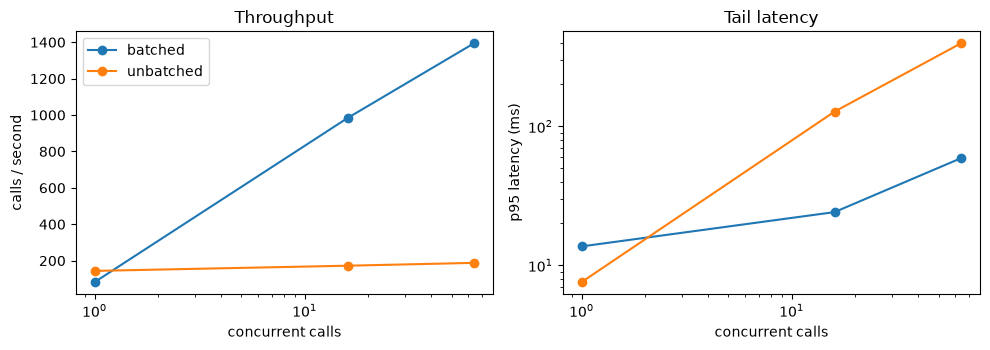

At 64 concurrent calls: batching gave 7.4× the throughput and 6.7× lower p95, with 24.0 images per model call.
At concurrency 1: mean batch 1.0, p95 13.7 ms batched vs 7.6 ms unbatched.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for label, group in batch_df.groupby("deployment"):
    axes[0].plot(group["concurrency"], group["rps"], marker="o", label=label)
    axes[1].plot(group["concurrency"], group["p95_ms"], marker="o", label=label)
axes[0].set(xscale="log", xlabel="concurrent calls", ylabel="calls / second", title="Throughput")
axes[1].set(xscale="log", yscale="log", xlabel="concurrent calls", ylabel="p95 latency (ms)", title="Tail latency")
axes[0].legend()
plt.tight_layout()
plt.show()

pivot = batch_df.pivot(index="concurrency", columns="deployment", values=["rps", "p95_ms", "mean_batch"])
top = int(batch_df["concurrency"].max())
print(f"At {top} concurrent calls: batching gave {pivot.loc[top, ('rps', 'batched')] / pivot.loc[top, ('rps', 'unbatched')]:.1f}× "
      f"the throughput and {pivot.loc[top, ('p95_ms', 'unbatched')] / pivot.loc[top, ('p95_ms', 'batched')]:.1f}× lower p95, "
      f"with {pivot.loc[top, ('mean_batch', 'batched')]:.1f} images per model call.")
print(f"At concurrency 1: mean batch {pivot.loc[1, ('mean_batch', 'batched')]:.1f}, "
      f"p95 {pivot.loc[1, ('p95_ms', 'batched')]:.1f} ms batched vs {pivot.loc[1, ('p95_ms', 'unbatched')]:.1f} ms unbatched.")
for app in ("forest-unbatched", "forest-batched"):
    serve.delete(app)

### ✍️ Your Turn

A deployment has **1 replica**, `@serve.batch(max_batch_size=64)`, and the **default** `max_ongoing_requests`. 200 calls arrive at once. What is the largest batch the method can ever receive? (Pitfall 2 measures it.)

In [14]:
largest_possible_batch = None  # TODO: a number
check("largest_possible_batch", largest_possible_batch, 5,
      hint="A replica only accepts max_ongoing_requests requests at a time — what is its default?")

⏳ largest_possible_batch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
largest_possible_batch = 5      # the default max_ongoing_requests caps what one replica holds at once
check("largest_possible_batch", largest_possible_batch, 5)
```

The other 195 calls wait in the caller-side queue until the replica has room. Set `max_ongoing_requests >= max_batch_size` whenever you batch.
</details>

> 💡 **Interview angle:** "`@serve.batch` vs BentoML adaptive batching vs vLLM continuous batching?" — `@serve.batch` is a per-replica request queue with a size cap and a fixed wait timeout. BentoML's dispatcher adapts its waiting to measured latency. vLLM batches at every **token-generation step** (continuous batching), which is what LLMs need, because sequences finish at different times.

## 6. Autoscaling: What Each Knob Does 🟡

Serve's default autoscaler watches **ongoing requests** (queued + running) per replica, not CPU. It aims for about `total ongoing requests ÷ target_ongoing_requests` replicas, kept within `[min_replicas, max_replicas]`, and slowed down by delays and smoothing factors so it doesn't flap. Pass `autoscaling_config={...}` to `@serve.deployment` instead of `num_replicas`:

| Knob | What it does | Tuning intuition |
|---|---|---|
| `min_replicas` / `max_replicas` | hard floor / ceiling | `min_replicas=0` allows scale-to-zero (cold starts!); set `max_replicas` from budget and cluster size |
| `initial_replicas` | replicas at first deploy (defaults to `min_replicas`) | pre-warm before a launch |
| `target_ongoing_requests` | desired queued+running requests **per replica** | lower → more replicas, lower latency, higher cost |
| `max_ongoing_requests` *(deployment option)* | hard cap a replica accepts; extra requests wait in the caller's queue | keep it above the target (and ≥ `max_batch_size` when batching) |
| `max_queued_requests` *(deployment option)* | cap on waiting requests; beyond it callers get an error | default −1 = unlimited; set it to shed load instead of timing out |
| `upscale_delay_s` / `downscale_delay_s` | how long a decision must hold before acting | quick up, slow down avoids flapping |
| `downscale_to_zero_delay_s` | extra wait before going from 1 → 0 replicas | protects against cold starts |
| `look_back_period_s` | window over which metrics are averaged | must be longer than the metrics interval |
| `upscaling_factor` / `downscaling_factor` | multiply each scaling step (a "gain") | < 1 = more cautious steps |
| `aggregation_function` | how the window is summarized (mean by default) | |

The defaults, read from the installed version:

In [15]:
defaults = AutoscalingConfig()
print({k: getattr(defaults, k) for k in ("min_replicas", "initial_replicas", "max_replicas", "target_ongoing_requests",
                                         "upscale_delay_s", "downscale_delay_s", "downscale_to_zero_delay_s",
                                         "look_back_period_s", "upscaling_factor", "downscaling_factor")})

{'min_replicas': 1, 'initial_replicas': None, 'max_replicas': 1, 'target_ongoing_requests': 2, 'upscale_delay_s': 30.0, 'downscale_delay_s': 600.0, 'downscale_to_zero_delay_s': None, 'look_back_period_s': 30.0, 'upscaling_factor': None, 'downscaling_factor': None}


**Live demo.** To see scaling within seconds we use a controlled stand-in for a slow model: a handler that takes a fixed 200 ms (`asyncio.sleep`). The autoscaler only sees request counts, so a real model behaves the same way. The delays are shortened for the demo. We send 12 concurrent callers for 15 seconds, then go quiet, and record the replica count every second.

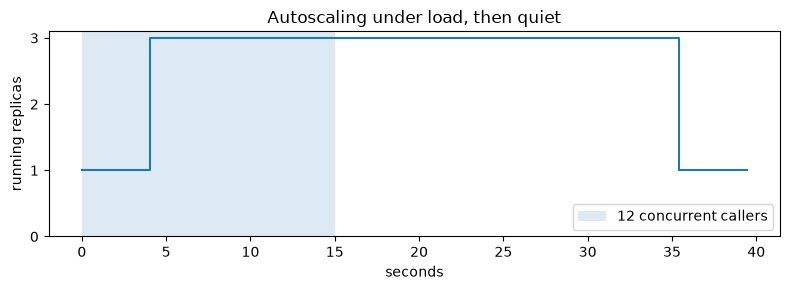

754 calls in 15s | peak 3 replicas, first reached at 4s (12 callers ÷ target 2 = 6 wanted, capped by max_replicas=3)
after the load stopped, replicas started to drop at 35s (20s later: look-back window + downscale delay)


In [16]:
@serve.deployment(
    ray_actor_options={"num_cpus": 0.25},
    max_ongoing_requests=8,
    autoscaling_config={"min_replicas": 1, "max_replicas": 3, "target_ongoing_requests": 2,
                        "upscale_delay_s": 1, "downscale_delay_s": 5, "look_back_period_s": 12},
)
class SlowStage:
    async def __call__(self, x: int) -> int:
        await asyncio.sleep(0.2)                           # controlled 200 ms "model"
        return x


slow_stage = serve.run(SlowStage.bind(), name="autoscale-demo", route_prefix=None)
LOAD_SECONDS, QUIET_SECONDS = 15, 25
timeline, completed = [], [0]                              # a list so the nested coroutines can update it
demo_start = time.perf_counter()


async def callers(n_callers, until):
    async def one_caller():
        while time.perf_counter() < until:
            await slow_stage.remote(1)
            completed[0] += 1
    await asyncio.gather(*(one_caller() for _ in range(n_callers)))


async def monitor(until):
    while time.perf_counter() < until:
        timeline.append((time.perf_counter() - demo_start, replica_counts("autoscale-demo")["SlowStage"]))
        await asyncio.sleep(1)


await asyncio.gather(callers(12, demo_start + LOAD_SECONDS), monitor(demo_start + LOAD_SECONDS))
await monitor(demo_start + LOAD_SECONDS + QUIET_SECONDS)
serve.delete("autoscale-demo")

scale_df = pd.DataFrame(timeline, columns=["seconds", "running_replicas"])
fig, ax = plt.subplots(figsize=(8, 3))
ax.step(scale_df["seconds"], scale_df["running_replicas"], where="post")
ax.axvspan(0, LOAD_SECONDS, alpha=0.15, label="12 concurrent callers")
ax.set(xlabel="seconds", ylabel="running replicas", title="Autoscaling under load, then quiet", yticks=[0, 1, 2, 3])
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

peak = int(scale_df["running_replicas"].max())
reached = scale_df.loc[scale_df["running_replicas"] == peak, "seconds"].min()
after_load = scale_df[scale_df["seconds"] > LOAD_SECONDS]
back_down = after_load.loc[after_load["running_replicas"] < peak, "seconds"].min()
print(f"{completed[0]} calls in {LOAD_SECONDS}s | peak {peak} replicas, first reached at {reached:.0f}s "
      f"(12 callers ÷ target 2 = 6 wanted, capped by max_replicas=3)")
if pd.notna(back_down):
    print(f"after the load stopped, replicas started to drop at {back_down:.0f}s "
          f"({back_down - LOAD_SECONDS:.0f}s later: look-back window + downscale delay)")
else:
    print(f"replicas had not scaled down within {QUIET_SECONDS}s of quiet")

> 💡 **Interview angle:** "Why autoscale model servers on queue depth / ongoing requests instead of CPU?" — GPU-bound or batched models can have low CPU while requests pile up, and an async replica waiting on I/O shows almost no CPU. Ongoing requests measure **demand against capacity** directly. Pair it with slow scale-down (hysteresis) and a warm minimum to avoid cold starts.

## 7. Resources: Fractional CPUs and GPUs 🟡

`ray_actor_options` tells Ray what one replica needs, and Ray only places a replica where that much is free:

- `{"num_cpus": 0.5}` — half a CPU. Many small replicas can share cores.
- `{"num_gpus": 0.25}` — a quarter GPU: four replicas share one GPU. This is **scheduling only**. Ray doesn't split GPU memory, so the models must actually fit together.
- `{"memory": 500 * 1024**2}` — reserve logical memory (bytes) so Ray doesn't overpack a node.
- `resources={"my_accelerator": 1}` — custom resources you define when starting nodes.

If no node has enough free resources, the replicas wait in a pending state, and on a real cluster the Ray autoscaler can add nodes.

In [17]:
async def wait_for_cpu_change(before, expected_drop, timeout_s=15):
    """Ray updates available resources asynchronously; poll until the reservation shows up."""
    deadline = time.perf_counter() + timeout_s
    while time.perf_counter() < deadline:
        now = ray.available_resources().get("CPU", 0.0)
        if math.isclose(before - now, expected_drop, abs_tol=1e-6):
            return now
        await asyncio.sleep(0.5)
    return ray.available_resources().get("CPU", 0.0)


@serve.deployment(num_replicas=3, ray_actor_options={"num_cpus": 0.5, "memory": 100 * 1024**2})
class HalfCPUReplica:
    def __call__(self) -> str:
        return serve.get_replica_context().replica_id.unique_id


cpu_before = ray.available_resources().get("CPU", 0.0)
serve.run(HalfCPUReplica.bind(), name="fractional", route_prefix=None)
cpu_after = await wait_for_cpu_change(cpu_before, expected_drop=1.5)
print(f"CPUs available: {cpu_before:.2f} → {cpu_after:.2f} after 3 replicas × 0.5 CPU (reserved {cpu_before - cpu_after:.2f})")
serve.delete("fractional")

n_gpus = ray.cluster_resources().get("GPU", 0)
if n_gpus:
    print(f"Ray detected {n_gpus:.0f} GPU(s) here, so ray_actor_options={{'num_gpus': 0.5}} would let 2 replicas share one. "
          "(Scheduling only: whether your library can use that GPU is separate — vLLM, for example, needs NVIDIA CUDA.)")
else:
    print("⏭️ No GPU visible to Ray here — try the `num_gpus` examples on a CUDA machine, e.g. Colab.")

CPUs available: 3.50 → 2.00 after 3 replicas × 0.5 CPU (reserved 1.50)


Ray detected 1 GPU(s) here, so ray_actor_options={'num_gpus': 0.5} would let 2 replicas share one. (Scheduling only: whether your library can use that GPU is separate — vLLM, for example, needs NVIDIA CUDA.)


> 💡 **Interview angle:** "How would you serve five small models on one GPU?" — fractional GPUs (`num_gpus=0.2` each) so the scheduler packs them onto one device, after checking that combined memory fits. Or **multiplexing** (next section) when the models share an architecture and not all of them are hot at once.

## 8. Model Multiplexing 🟡

**Multiplexing** serves *many* models of the same kind (e.g. one fine-tuned model per customer) from a *shared* pool of replicas. Each replica keeps an **LRU cache** (least recently used) of at most `max_num_models_per_replica` models. The router prefers replicas that already have the requested model loaded.

- Mark the loader: `@serve.multiplexed(max_num_models_per_replica=2) async def get_model(self, model_id)`.
- Inside a request: `model = await self.get_model(serve.get_multiplexed_model_id())`.
- Callers pick a model with `handle.options(multiplexed_model_id="tenant-a")`, or over HTTP with the `serve_multiplexed_model_id` header.

We train three real "tenant" models: logistic regressions on different random halves of the digits training data. The deployment records every time it has to load one from disk.

In [18]:
TENANT_DIR = RAY_DIR / "tenants"
TENANT_DIR.mkdir(exist_ok=True)
tenant_models = {}
for i, tenant in enumerate(["tenant-a", "tenant-b", "tenant-c"]):
    subset = np.random.default_rng(i).choice(len(X_train), size=len(X_train) // 2, replace=False)
    tenant_models[tenant] = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train[subset], y_train[subset])
    joblib.dump(tenant_models[tenant], TENANT_DIR / f"{tenant}.joblib")


@serve.deployment(num_replicas=1, ray_actor_options={"num_cpus": 0.25})
class TenantModels:
    def __init__(self, model_dir: str):
        self.model_dir = Path(model_dir)
        self.loads = []                                      # every disk load, in order

    @serve.multiplexed(max_num_models_per_replica=2)
    async def get_model(self, model_id: str):
        self.loads.append(model_id)
        return joblib.load(self.model_dir / f"{model_id}.joblib")

    async def __call__(self, pixels: list[float]) -> int:
        model = await self.get_model(serve.get_multiplexed_model_id())
        return int(model.predict(np.array([pixels]))[0])

    def load_history(self) -> list[str]:
        return self.loads


tenants = serve.run(TenantModels.bind(str(TENANT_DIR.resolve())), name="tenants", route_prefix=None)

### ✍️ Your Turn

Requests arrive for tenants in this order: `a, b, a, c, a, b` (as `tenant-a`, …). The replica caches **2** models, evicting the least recently used. **Predict** the list of models it will load from disk, in order, *before* running the next cell.

In [19]:
predicted_loads = None  # TODO: a list like ["tenant-a", ...]
check("predicted_loads", predicted_loads, ["tenant-a", "tenant-b", "tenant-c", "tenant-b"],
      hint="a (load) · b (load) · a (cached) · c (load, evicts the least recently used: b) · a (cached) · b (?)")

⏳ predicted_loads: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
predicted_loads = ["tenant-a", "tenant-b", "tenant-c", "tenant-b"]
check("predicted_loads", predicted_loads, ["tenant-a", "tenant-b", "tenant-c", "tenant-b"])
```

After `a, b, a` the cache holds {b, a} with `a` most recent. `c` evicts `b`. `a` is a hit. `b` must be loaded again (evicting `c`).
</details>

In [20]:
sequence = ["tenant-a", "tenant-b", "tenant-a", "tenant-c", "tenant-a", "tenant-b"]
served_predictions = [await tenants.options(multiplexed_model_id=t).remote(X_test[i].tolist()) for i, t in enumerate(sequence)]
local_predictions = [int(tenant_models[t].predict(X_test[i:i + 1])[0]) for i, t in enumerate(sequence)]
assert served_predictions == local_predictions
print("predictions match each tenant's own model ✅")
print("models loaded from disk, in order:", await tenants.load_history.remote())
serve.delete("tenants")

predictions match each tenant's own model ✅
models loaded from disk, in order: ['tenant-a', 'tenant-b', 'tenant-c', 'tenant-b']


> 💡 **Interview angle:** "Serve 1,000 per-customer LoRA adapters or small models" — don't run 1,000 deployments. Multiplex them onto a shared replica pool with an LRU cache and model-aware routing. Size the cache from memory and traffic skew (a few hot tenants), and watch cache-miss latency. Ray Serve LLM uses the same idea for multi-LoRA serving.

## 9. Config Files, serve build, and serve deploy 🟡

In production you don't call `serve.run` from a notebook. You describe applications in a **YAML config** and apply it to a long-running cluster:

```bash
serve build digits_app:app -o digits_config.yaml   # generate a config from an importable application
serve run digits_config.yaml                       # local development: run it and stream logs
ray start --head                                   # a long-running cluster (or KubeRay on Kubernetes)
serve deploy digits_config.yaml                    # send the config to the cluster's dashboard API (http://localhost:8265)
serve status                                       # check health
```

The config holds only **settings** (replicas, autoscaling, resources, route prefix) plus an **import path**. The code ships separately (in the image, or through `runtime_env`). Changing `num_replicas` in YAML and re-deploying updates the running app without touching code. On Kubernetes, **KubeRay's `RayService`** embeds this same config.

We write the digits classifier as an importable module, generate its config with the real `serve build` CLI, edit it, and validate it against Serve's schema. (`serve deploy` needs a `ray start` cluster with the dashboard, which we don't run on this laptop.)

In [21]:
(APPS_DIR / "digits_app.py").write_text('''"""Digits classifier as an importable Serve application (for `serve build` / `serve run`)."""
from pathlib import Path

import joblib
import numpy as np
from ray import serve

MODEL_PATH = Path(__file__).with_name("digits_forest.joblib")


@serve.deployment(num_replicas=1, ray_actor_options={"num_cpus": 0.5}, max_ongoing_requests=32)
class DigitClassifier:
    def __init__(self, model_path: str = str(MODEL_PATH)):
        self.model = joblib.load(model_path)

    def __call__(self, pixels: list[list[float]]) -> list[int]:
        return self.model.predict(np.asarray(pixels)).tolist()


app = DigitClassifier.bind()
''')

serve_cli = str(Path(sys.executable).parent / "serve")
build = subprocess.run([serve_cli, "build", "digits_app:app", "-o", "digits_config.yaml"],
                       cwd=APPS_DIR, capture_output=True, text=True, timeout=300)
assert build.returncode == 0, build.stderr[-2000:]
config_text = (APPS_DIR / "digits_config.yaml").read_text()
print(config_text[config_text.index("applications:"):])

applications:
- name: app1
  route_prefix: /
  import_path: digits_app:app
  runtime_env: {}
  deployments:
  - name: DigitClassifier
    num_replicas: 1
    max_ongoing_requests: 32
    ray_actor_options:
      num_cpus: 0.5



In [22]:
sys.path.insert(0, str(APPS_DIR.resolve()))
import digits_app                                          # noqa: E402 — the module was just written
digits_app = importlib.reload(digits_app)
module_handle = serve.run(digits_app.app, name="digits-module", route_prefix=None)
print("app from the module predicts:", await module_handle.remote(X_test[:5].tolist()), "| true:", y_test[:5].tolist())
serve.delete("digits-module")

app from the module predicts: [1, 0, 9, 1, 5] | true: [1, 0, 9, 1, 5]


### ✍️ Your Turn

Load the generated YAML, change the `DigitClassifier` deployment to **3 replicas**, and validate the result with `ServeDeploySchema.model_validate(...)`. Store the validated replica count in `validated_replicas`.

In [23]:
validated_replicas = None  # TODO
check("validated_replicas", validated_replicas, 3,
      hint='cfg = yaml.safe_load(config_text); cfg["applications"][0]["deployments"][0]["num_replicas"] = 3; '
           'ServeDeploySchema.model_validate(cfg).applications[0].deployments[0].num_replicas')

⏳ validated_replicas: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cfg = yaml.safe_load(config_text)
cfg["applications"][0]["deployments"][0]["num_replicas"] = 3
validated = ServeDeploySchema.model_validate(cfg)
validated_replicas = validated.applications[0].deployments[0].num_replicas
(APPS_DIR / "digits_config_3_replicas.yaml").write_text(yaml.safe_dump(cfg, sort_keys=False))
check("validated_replicas", validated_replicas, 3)
```

Validating configs in CI catches typos (like the renamed `target_num_ongoing_requests_per_replica`) before a deploy fails.
</details>

> 💡 **Interview angle:** "How do you do zero-downtime model updates on Ray Serve?" — keep code and config declarative: build a new image, update the config (import path, `user_config`, or replicas), and let Serve roll replicas gradually. On Kubernetes, KubeRay's `RayService` can bring up a new cluster, wait until it's healthy, then switch traffic. Change only `user_config` for lightweight updates that don't restart replicas.

## 10. Observability: Status, Logs, and Metrics 🟢

Three layers, from quick checks to dashboards:

1. **`serve.status()`** (or `serve status` in a terminal): application and deployment health and replica states.
2. **Logs**: one file per controller, proxy, and replica under the session's `logs/serve/` folder, including access logs with latency. `logging.getLogger("ray.serve")` inside a deployment writes there too, and `logging_config` can switch it to JSON.
3. **Metrics**: every node exposes Prometheus metrics (`ray_serve_*`: request counts, latencies, queue sizes, batch sizes, autoscaling decisions). You can add your own with `ray.serve.metrics.Counter` / `Gauge` / `Histogram`. In production, Prometheus scrapes them and Grafana shows the Serve dashboards.

We send traffic to the `digits` HTTP app from section 3, then look at all three.

In [24]:
for i in range(30):
    httpx.post(f"{DIGITS_URL}/predict", json={"pixels": X_test[i].tolist()})

status_rows = [{"application": app_name, "app_status": app.status.value, "deployment": dep_name,
                "deployment_status": dep.status.value, "replicas": dict(dep.replica_states)}
               for app_name, app in serve.status().applications.items() for dep_name, dep in app.deployments.items()]
display(pd.DataFrame(status_rows))

serve_logs = Path(ray_context.address_info["session_dir"]) / "logs" / "serve"
log_files = sorted(p.name for p in serve_logs.glob("*.log"))
print(f"{len(log_files)} Serve log files, e.g.:", [f for f in log_files if f.startswith(("controller", "proxy"))][:2],
      [f for f in log_files if "DigitService" in f][:1])
digit_log = next(serve_logs.glob("replica_digits_DigitService_*.log"))
access_lines = [line for line in digit_log.read_text().splitlines() if "/predict" in line]
print("latest access-log entry:", access_lines[-1].split(" -- ")[-1] if access_lines else "(none yet)")

,application,app_status,deployment,deployment_status,replicas
0,digits,RUNNING,DigitService,HEALTHY,{'RUNNING': 1}


19 Serve log files, e.g.: ['controller_33026.log', 'proxy_127.0.0.1.log'] ['replica_digits_DigitService_il1vmzqw.log']
latest access-log entry: POST /digits/predict 200 10.1ms


In [25]:
metrics_url = f"http://127.0.0.1:{ray_context.address_info['metrics_export_port']}/metrics"
serve_metric_names, http_requests = [], 0.0
for _ in range(30):                                        # metrics are pushed on an interval; wait up to ~30 s
    metrics_text = httpx.get(metrics_url, timeout=10).text
    serve_metric_names = sorted({line.split("{")[0] for line in metrics_text.splitlines() if line.startswith("ray_serve_")})
    http_requests = sum(float(line.rsplit(" ", 1)[1]) for line in metrics_text.splitlines()
                        if line.startswith("ray_serve_num_http_requests_total{") and "/digits" in line)
    if http_requests >= 30:
        break
    await asyncio.sleep(1)
print(f"{len(serve_metric_names)} built-in ray_serve_* metrics, e.g. {serve_metric_names[:4]}")
print(f"ray_serve_num_http_requests_total for /digits: {http_requests:.0f}")

66 built-in ray_serve_* metrics, e.g. ['ray_serve_application_status', 'ray_serve_autoscaling_handle_metrics_delay_ms_bucket', 'ray_serve_autoscaling_handle_metrics_delay_ms_count', 'ray_serve_autoscaling_handle_metrics_delay_ms_sum']
ray_serve_num_http_requests_total for /digits: 34


> 💡 **Interview angle:** "What would you put on a model-serving dashboard?" — request rate, error rate, **p50/p95/p99 latency** per deployment, **queue length / ongoing requests** (the autoscaling signal), replica count and restarts, batch-size distribution, GPU utilization and memory, plus model-quality signals (prediction distribution, drift) logged next to the model version.

## 11. LLM Serving on Ray: Ray Serve LLM and vLLM 🟡

Serving an LLM is different from serving a classifier: generation is **token by token**, the **KV cache** fills GPU memory, and big models need several GPUs. **Ray Serve LLM** (`ray.serve.llm`, installed with `pip install "ray[llm]"`) combines Ray Serve with an inference engine, **vLLM** (SGLang is also supported):

- `LLMConfig` describes the model, the engine settings (e.g. tensor parallelism), the accelerator type, LoRA adapters, and the deployment/autoscaling config.
- `build_openai_app(...)` builds an application with an **OpenAI-compatible API** (`/v1/chat/completions`, `/v1/completions`, `/v1/embeddings`), so existing OpenAI clients just change their base URL.
- vLLM provides **continuous batching** and **PagedAttention** (KV-cache memory in pages). Ray adds multi-node placement, autoscaling, multi-LoRA via multiplexing, prefix-cache-aware routing, and prefill/decode disaggregation.

```python
from ray import serve
from ray.serve.llm import LLMConfig, build_openai_app

llm_config = LLMConfig(
    model_loading_config={"model_id": "qwen-0.5b", "model_source": "Qwen/Qwen2.5-0.5B-Instruct"},
    deployment_config={"autoscaling_config": {"min_replicas": 1, "max_replicas": 2}},
    accelerator_type="A10G",
    engine_kwargs={"tensor_parallel_size": 1},
)
serve.run(build_openai_app({"llm_configs": [llm_config]}), blocking=True)
# then: OpenAI(base_url="http://localhost:8000/v1", api_key="fake").chat.completions.create(model="qwen-0.5b", ...)
```

vLLM needs an NVIDIA (or other supported) GPU, so the cell below only checks prerequisites and does **not** fake a response.

In [26]:
has_vllm = importlib.util.find_spec("vllm") is not None
if has_vllm and ray.cluster_resources().get("GPU", 0) > 0:
    print("✅ vLLM and a GPU are available: the LLMConfig example above can run here (it downloads the model).")
else:
    print(f"⏭️ Skipped: Ray Serve LLM needs vLLM (installed: {has_vllm}) and a GPU visible to Ray "
          f"(GPUs: {ray.cluster_resources().get('GPU', 0):.0f}). Try it on a CUDA machine or Colab with `pip install \"ray[llm]\"`.")

⏭️ Skipped: Ray Serve LLM needs vLLM (installed: False) and a GPU visible to Ray (GPUs: 1). Try it on a CUDA machine or Colab with `pip install "ray[llm]"`.


> 💡 **Interview angle:** "Design an LLM serving stack." — an engine with continuous batching and paged KV cache (vLLM/SGLang/TensorRT-LLM) → a serving layer for replicas, autoscaling on queue depth or KV-cache use, and routing (prefix-cache affinity, LoRA-aware) → an OpenAI-compatible gateway with rate limits, streaming, and metrics (time-to-first-token, tokens/s). Say where tensor parallelism (a model too big for one GPU) and replica scaling (throughput) each fit.

## 12. Ray Serve vs BentoML vs KServe vs Triton 🟡

| | **Ray Serve** | **BentoML** | **KServe** | **NVIDIA Triton** |
|---|---|---|---|---|
| What it is | serving library on the Ray distributed runtime | Python serving framework + packaging (Bentos) | Kubernetes platform (CRDs) for model serving | high-performance C++ inference server |
| Unit of scale | deployment replicas (actors) across a Ray cluster | service workers; BentoCloud or K8s replicas | pods, via Knative/HPA, scale-to-zero | model instances per GPU |
| Composition | handles, replica → replica, independent scaling | `bentoml.depends` | InferenceGraph | ensembles / Python backend |
| Batching | `@serve.batch` (plus vLLM inside Ray Serve LLM) | adaptive batching | runtime-specific | dynamic batcher |
| Autoscaling signal | ongoing requests per replica | BentoCloud: concurrency/queue | request concurrency (Knative) or CPU | external (K8s) |
| Config | Python or YAML (`serve deploy`, KubeRay RayService) | decorators + `bentofile.yaml` | `InferenceService` YAML | `config.pbtxt` per model |
| Best when | many models, Python-heavy pipelines, LLM serving, you already use Ray | a team wants batteries-included Python serving and packaging | the platform is Kubernetes and many teams deploy models the same way | GPU throughput per dollar on exportable models |

They combine too: KServe or KubeRay on Kubernetes, Triton or vLLM as the engine, and Ray Serve or BentoML for Python orchestration.

> 💡 **Interview angle:** "When is Ray Serve overkill?" — a single model on one machine with modest traffic: FastAPI or BentoML is simpler to run and debug. Ray Serve pays off when you need several models with different hardware, cluster-wide autoscaling, or you're already running Ray for training and data processing.

## 🔧 Build It From Scratch

Every serving system has a **router** that decides which replica gets the next request. We build four and race them:

| Router | Rule | Needs to know |
|---|---|---|
| **Round-robin** | take turns: 0, 1, 2, 3, 0, … | nothing |
| **Random** | pick uniformly at random | nothing |
| **Least-loaded** | pick the replica with the fewest ongoing requests | *every* replica's load (costly at scale, can be stale) |
| **Power of two choices** | sample **2** replicas at random, send to the less loaded one | the load of just 2 replicas |

Power of two choices is Ray Serve's default router (`PowerOfTwoChoicesRequestRouter`). Classic results (Mitzenmacher's "power of two choices") show that checking just two random options removes most of the gap between random and fully least-loaded routing.

**Setup (a controlled experiment):** 4 replicas are **threads**, each with its own FIFO queue. Each runs a real model (a digits logistic regression) and then `time.sleep`s. The sleep stands in for GPU or network time and releases Python's GIL. Three replicas take ~4 ms; **one is a slow "noisy neighbour" at ~24 ms**, the kind of replica you get on an overloaded node. Requests arrive at random (Poisson), 400 per second. Latency is measured from each request's arrival to its completion.

p2c unit test ✅ | pick share: {'r1': 0.5, 'r2': 0.34, 'r0': 0.15}


✅ every router returned the model's correct prediction for every request


,p50_ms,p99_ms,max_ms,share_to_slow_replica
RoundRobin,6.01,4342.78,4488.69,0.25
Random,8.97,4320.22,4476.40,0.25
LeastLoaded,5.78,51.67,76.61,0.09
PowerOfTwo,6.40,69.07,82.12,0.09


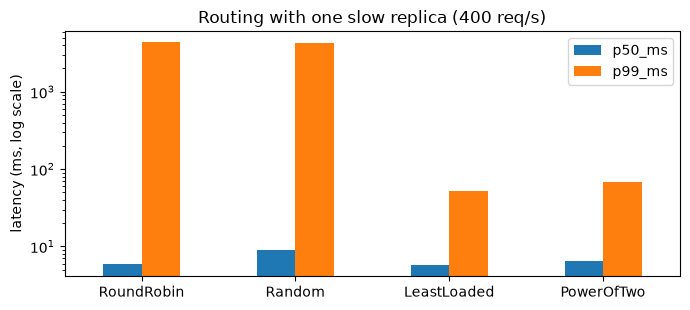

Round-robin sent 25% of requests to the slow replica → p99 4343 ms.
Power of two choices sent 9% → p99 69 ms (63× better tail latency while sampling only 2 replicas per request).


In [27]:
fast_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train, y_train)
REPLICA_EXTRA_MS = [4, 4, 4, 24]                          # replica 3 is the noisy neighbour


class ThreadReplica:
    """A worker thread with its own FIFO queue — a stand-in for one Serve replica."""

    def __init__(self, name, model, extra_ms):
        self.name, self.model, self.extra_s = name, model, extra_ms / 1000
        self.inbox = queue.Queue()
        self.ongoing = 0                                   # queued + running (what Serve's router looks at)
        self.lock = threading.Lock()
        self.thread = threading.Thread(target=self._loop, daemon=True)
        self.thread.start()

    def submit(self, request):
        with self.lock:
            self.ongoing += 1
        self.inbox.put(request)

    def _loop(self):
        while (request := self.inbox.get()) is not None:
            request["prediction"] = int(self.model.predict(request["x"][None, :])[0])
            time.sleep(self.extra_s)                       # the rest of the work (GPU / network), releases the GIL
            request["done"] = time.perf_counter()
            with self.lock:
                self.ongoing -= 1
            request["event"].set()

    def stop(self):
        self.inbox.put(None)
        self.thread.join()


class RoundRobinRouter:
    def __init__(self, replicas, rng):
        self.replicas, self.turn = replicas, itertools.cycle(range(len(replicas)))

    def choose(self):
        return self.replicas[next(self.turn)]


class RandomRouter:
    def __init__(self, replicas, rng):
        self.replicas, self.rng = replicas, rng

    def choose(self):
        return self.rng.choice(self.replicas)


class LeastLoadedRouter:
    def __init__(self, replicas, rng):
        self.replicas, self.rng = replicas, rng

    def choose(self):
        return min(self.replicas, key=lambda r: (r.ongoing, self.rng.random()))   # random tie-break


class PowerOfTwoRouter:
    def __init__(self, replicas, rng):
        self.replicas, self.rng = replicas, rng

    def choose(self):
        first, second = self.rng.sample(self.replicas, 2)
        return first if first.ongoing <= second.ongoing else second


# Unit test: power of two choices never picks the busier of the two replicas it sampled
fake = [SimpleNamespace(name=f"r{i}", ongoing=q) for i, q in enumerate([7, 0, 3, 9])]
probe_router = PowerOfTwoRouter(fake, random.Random(0))
picks = [probe_router.choose() for _ in range(200)]
assert all(p.ongoing != 9 for p in picks), "the busiest replica can only lose a comparison"
print("p2c unit test ✅ | pick share:", {n: round(c / len(picks), 2) for n, c in pd.Series([p.name for p in picks]).value_counts().items()})


def simulate(router_cls, rate_per_s=400, n_requests=1000, seed=0):
    arrivals = random.Random(seed)
    replicas = [ThreadReplica(f"r{i}", fast_model, ms) for i, ms in enumerate(REPLICA_EXTRA_MS)]
    router = router_cls(replicas, random.Random(seed + 1))
    requests, next_arrival = [], time.perf_counter()
    for i in range(n_requests):
        next_arrival += arrivals.expovariate(rate_per_s)   # Poisson arrivals: random gaps, 400/s on average
        wait = next_arrival - time.perf_counter()
        if wait > 0:
            time.sleep(wait)
        request = {"x": X_test[i % len(X_test)], "arrival": next_arrival, "event": threading.Event()}
        chosen = router.choose()
        request["replica"] = chosen.name
        chosen.submit(request)
        requests.append(request)
    for request in requests:
        request["event"].wait()
    for replica in replicas:
        replica.stop()
    latency_ms = np.array([(r["done"] - r["arrival"]) * 1000 for r in requests])
    predictions = np.array([r["prediction"] for r in requests])
    slow_share = np.mean([r["replica"] == "r3" for r in requests])
    stats = {"p50_ms": np.percentile(latency_ms, 50), "p99_ms": np.percentile(latency_ms, 99),
             "max_ms": latency_ms.max(), "share_to_slow_replica": slow_share}
    return stats, predictions


router_results = {}
expected_router_preds = fast_model.predict(np.array([X_test[i % len(X_test)] for i in range(1000)]))
for router_cls in (RoundRobinRouter, RandomRouter, LeastLoadedRouter, PowerOfTwoRouter):
    stats, predictions = simulate(router_cls)
    assert np.array_equal(predictions, expected_router_preds), f"{router_cls.__name__} returned wrong predictions"
    router_results[router_cls.__name__.replace("Router", "")] = stats
print("✅ every router returned the model's correct prediction for every request")

router_df = pd.DataFrame(router_results).T
display(router_df.round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
router_df[["p50_ms", "p99_ms"]].plot.bar(ax=ax, logy=True, rot=0)
ax.set(ylabel="latency (ms, log scale)", title="Routing with one slow replica (400 req/s)")
plt.tight_layout()
plt.show()

rr, p2c = router_results["RoundRobin"], router_results["PowerOfTwo"]
print(f"Round-robin sent {rr['share_to_slow_replica']:.0%} of requests to the slow replica → p99 {rr['p99_ms']:.0f} ms.")
print(f"Power of two choices sent {p2c['share_to_slow_replica']:.0%} → p99 {p2c['p99_ms']:.0f} ms "
      f"({rr['p99_ms'] / p2c['p99_ms']:.0f}× better tail latency while sampling only 2 replicas per request).")

**Why round-robin loses:** it gives the slow replica 25% of the traffic, but that replica can only handle about 40 requests/s of the 100/s it receives. Its queue grows for the whole run, and those requests become the p99. Load-aware routers notice the queue and send it less work. Ray Serve's router works the same way, and it also respects each replica's `max_ongoing_requests`, prefers local replicas, and handles multiplexed model IDs.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Calling `.result()` inside an async deployment

In [28]:
@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Tripler:
    def __call__(self, x: int) -> int:
        return 3 * x


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Caller:
    def __init__(self, tripler: DeploymentHandle):
        self.tripler = tripler

    async def wrong(self, x: int) -> int:
        return self.tripler.remote(x).result()             # ❌ blocking wait inside the replica's event loop

    async def right(self, x: int) -> int:
        return await self.tripler.remote(x)                 # ✅ yields while waiting


caller = serve.run(Caller.bind(Tripler.bind()), name="pitfall-result", route_prefix=None)
try:
    await caller.wrong.remote(5)
except Exception as err:                                    # the RuntimeError comes back wrapped in a RayTaskError
    print("❌ wrong:", type(err).__name__, "→", str(err).strip().splitlines()[-1])
print("✅ right:", await caller.right.remote(5))
serve.delete("pitfall-result")

❌ wrong: RayTaskError(RuntimeError) → RuntimeError: Sync methods should not be called from within an `asyncio` event loop. Use `await response` instead.
✅ right: 15


### ❌ Pitfall 2 — `@serve.batch` with the default `max_ongoing_requests`

In [29]:
@serve.deployment(ray_actor_options={"num_cpus": 1})                            # ❌ default max_ongoing_requests
class BatchedDefault:
    def __init__(self, model_path: str):
        self.model = joblib.load(model_path)
        self.batch_sizes = []

    @serve.batch(max_batch_size=64, batch_wait_timeout_s=0.005)
    async def __call__(self, batch: list[list[float]]) -> list[int]:
        self.batch_sizes.append(len(batch))
        return self.model.predict(np.array(batch)).tolist()

    def sizes(self) -> list[int]:
        return self.batch_sizes


BatchedWide = BatchedDefault.options(name="BatchedWide", max_ongoing_requests=128)   # ✅ room for full batches
cap_rows = []
for label, deployment in (("❌ default max_ongoing_requests", BatchedDefault), ("✅ max_ongoing_requests=128", BatchedWide)):
    handle = serve.run(deployment.bind(forest_path), name="pitfall-batch", route_prefix=None)
    await handle_load_test(handle, image_payloads[:64], concurrency=64)            # warm-up
    stats, outputs = await handle_load_test(handle, image_payloads, concurrency=64, setting=label)
    assert outputs == expected_digits
    sizes = await handle.sizes.remote()
    stats.update(mean_batch=float(np.mean(sizes)), max_batch=int(max(sizes)))
    cap_rows.append(stats)
    serve.delete("pitfall-batch")
display(pd.DataFrame(cap_rows)[["setting", "rps", "p95_ms", "mean_batch", "max_batch"]].round(1))

,setting,rps,p95_ms,mean_batch,max_batch
0,❌ default max_ongoing_requests,206.2,521.4,5.0,5
1,✅ max_ongoing_requests=128,1758.1,44.9,24.6,51


### ❌ Pitfall 3 — Blocking calls in a replica

In Ray 2.58, sync `def` methods run **directly on the replica's event loop** (setting `RAY_SERVE_RUN_SYNC_IN_THREADPOOL=1` opts into a thread pool). A blocking wait, like a `requests.get` to a feature store (here `time.sleep` stands in for it), makes every other request on that replica wait.

In [30]:
@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class FeatureLookup:
    def blocking(self, seconds: float) -> float:
        time.sleep(seconds)                                  # ❌ blocks the replica
        return seconds

    async def non_blocking(self, seconds: float) -> float:
        await asyncio.sleep(seconds)                         # ✅ async I/O lets requests overlap
        return seconds


lookup = serve.run(FeatureLookup.bind(), name="pitfall-blocking", route_prefix=None)
await lookup.non_blocking.remote(0.0)
with Timer() as t_block:
    await asyncio.gather(*(lookup.blocking.remote(0.25) for _ in range(8)))
with Timer() as t_async:
    await asyncio.gather(*(lookup.non_blocking.remote(0.25) for _ in range(8)))
print(f"❌ 8 concurrent blocking 0.25 s calls: {t_block.seconds:.2f}s")
print(f"✅ 8 concurrent async 0.25 s calls   : {t_async.seconds:.2f}s → {t_block.seconds / t_async.seconds:.1f}× faster")
serve.delete("pitfall-blocking")

❌ 8 concurrent blocking 0.25 s calls: 2.19s
✅ 8 concurrent async 0.25 s calls   : 0.64s → 3.4× faster


### ❌ Pitfall 4 — Two applications with the same route prefix

In [31]:
try:
    serve.run(Greeter.bind(greeting="Hi"), name="greeter-2", route_prefix="/digits")   # ❌ /digits is taken
except Exception as err:
    lines = [line.strip() for line in str(err).splitlines() if line.strip()]
    message = next((line for line in reversed(lines) if "prefix" in line.lower()), lines[-1] if lines else "")
    print("❌", type(err).__name__, "→", message[:200])
serve.run(Greeter.bind(greeting="Hi"), name="greeter-2", route_prefix="/greet-2")      # ✅ unique prefix
print("✅ /greet-2 →", httpx.get(f"{SERVE_URL}/greet-2", params={"name": "Ada"}).json()["message"])
serve.delete("greeter-2")

❌ RayTaskError(RayServeException) → ray.serve.exceptions.RayServeException: Prefix /digits is being used by application "digits". Failed to deploy application "greeter-2".


✅ /greet-2 → Hi, Ada!


### ❌ Pitfall 5 — An autoscaling window shorter than the metrics interval

`look_back_period_s` must be longer than the interval at which replicas report metrics (10 s by default). Otherwise the autoscaler averages over too few points, and Ray warns that this will become an error.

In [32]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    AutoscalingConfig(min_replicas=1, max_replicas=4, look_back_period_s=2)       # ❌
print("❌ look_back_period_s=2  →", [f"{w.category.__name__}: {str(w.message)[:110]}" for w in caught])
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    AutoscalingConfig(min_replicas=1, max_replicas=4, look_back_period_s=15)      # ✅
print("✅ look_back_period_s=15 → warnings:", len(caught))

❌ look_back_period_s=2  → ['FutureWarning: `look_back_period_s` (2.0) must be greater than `metrics_interval_s` (10.0). This will raise an exception in a']
✅ look_back_period_s=15 → warnings: 0


### ❌ Pitfall 6 — Loading the model per request instead of in `__init__`

In [33]:
@serve.deployment(ray_actor_options={"num_cpus": 0.5})
class LoadEveryCall:
    def __init__(self, model_path: str):
        self.model_path = model_path

    def __call__(self, pixels: list[float]) -> int:
        model = joblib.load(self.model_path)                # ❌ disk read + unpickle every request
        return int(model.predict(np.array([pixels]))[0])


@serve.deployment(ray_actor_options={"num_cpus": 0.5})
class LoadOnce:
    def __init__(self, model_path: str):
        self.model = joblib.load(model_path)                # ✅ once per replica

    def __call__(self, pixels: list[float]) -> int:
        return int(self.model.predict(np.array([pixels]))[0])


load_rows = []
for label, deployment in (("❌ load per request", LoadEveryCall), ("✅ load in __init__", LoadOnce)):
    handle = serve.run(deployment.bind(forest_path), name="pitfall-load", route_prefix=None)
    await handle.remote(image_payloads[0])                  # warm-up
    stats, outputs = await handle_load_test(handle, image_payloads[:40], concurrency=1, setting=label)
    assert outputs == expected_digits[:40]
    load_rows.append(stats)
    serve.delete("pitfall-load")
load_df = pd.DataFrame(load_rows).set_index("setting")
display(load_df[["rps", "p50_ms"]].round(1))
print(f"loading per request made the median call {load_df['p50_ms'].iloc[0] / load_df['p50_ms'].iloc[1]:.0f}× slower")

,rps,p50_ms
setting,,
❌ load per request,50.2,19.4
✅ load in __init__,179.9,5.4


loading per request made the median call 4× slower


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Parallel evaluation with Ray tasks
Put `forest` in the object store once, split the test set into **4 chunks** (`np.array_split`), count correct predictions per chunk in parallel with `chunk_correct.remote`, and add them up.

In [34]:
@ray.remote
def chunk_correct(model, X_chunk, y_chunk):
    return int((model.predict(X_chunk) == y_chunk).sum())


total_correct = None  # TODO
check("total_correct", total_correct, int((forest.predict(X_test) == y_test).sum()),
      hint="forest_ref = ray.put(forest); refs = [chunk_correct.remote(forest_ref, Xc, yc) for Xc, yc in zip(np.array_split(X_test, 4), np.array_split(y_test, 4))]")

⏳ total_correct: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@ray.remote
def chunk_correct(model, X_chunk, y_chunk):
    return int((model.predict(X_chunk) == y_chunk).sum())


forest_ref = ray.put(forest)                               # upload the model once, share it with every task
refs = [chunk_correct.remote(forest_ref, X_chunk, y_chunk)
        for X_chunk, y_chunk in zip(np.array_split(X_test, 4), np.array_split(y_test, 4))]
total_correct = sum(ray.get(refs))
check("total_correct", total_correct, int((forest.predict(X_test) == y_test).sum()))
```

Passing `forest` directly to each `.remote` call would serialize it 4 times; `ray.put` stores it once.
</details>

### 🟢 Exercise 2 — Write an autoscaling config
Requirements: never fewer than **1** replica, at most **8**, aim for **4** ongoing requests per replica, and wait **5 minutes** before scaling down. Write it as a dict `scaling_config`. The checker builds `AutoscalingConfig(**scaling_config)`, so misspelled keys fail.

In [35]:
scaling_config = None  # TODO: a dict
check("scaling_config", None if scaling_config is None else
      (lambda c: [c.min_replicas, c.max_replicas, c.target_ongoing_requests, c.downscale_delay_s])(AutoscalingConfig(**scaling_config)),
      [1, 8, 4, 300], hint="keys: min_replicas, max_replicas, target_ongoing_requests, downscale_delay_s (seconds)")

⏳ scaling_config: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scaling_config = {"min_replicas": 1, "max_replicas": 8, "target_ongoing_requests": 4, "downscale_delay_s": 300}
check("scaling_config",
      (lambda c: [c.min_replicas, c.max_replicas, c.target_ongoing_requests, c.downscale_delay_s])(AutoscalingConfig(**scaling_config)),
      [1, 8, 4, 300])
```

Old tutorials use `target_num_ongoing_requests_per_replica`, which was renamed to `target_ongoing_requests`.
</details>

### 🟢 Exercise 3 — Your own deployment
Create a deployment `Doubler` with **2 replicas** (0.25 CPU each) whose `__call__` doubles every number in a list. Deploy it with `serve.run(..., name="doubler", route_prefix=None)`, store `await handle.remote([1, 2, 3])` in `doubled`, then `serve.delete("doubler")`.

In [36]:
doubled = None  # TODO
check("doubled", doubled, [2, 4, 6], hint="@serve.deployment(num_replicas=2, ray_actor_options={'num_cpus': 0.25}) class Doubler: def __call__(self, values): ...")

⏳ doubled: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@serve.deployment(num_replicas=2, ray_actor_options={"num_cpus": 0.25})
class Doubler:
    def __call__(self, values: list[int]) -> list[int]:
        return [2 * v for v in values]


doubler = serve.run(Doubler.bind(), name="doubler", route_prefix=None)
doubled = await doubler.remote([1, 2, 3])
serve.delete("doubler")
check("doubled", doubled, [2, 4, 6])
```
</details>

### 🟡 Exercise 4 — The autoscaling formula
Write `desired_replicas(total_ongoing, target, min_replicas, max_replicas)`, the simplified core of Serve's default policy: `ceil(total_ongoing / target)`, clipped to `[min_replicas, max_replicas]`.

In [37]:
def desired_replicas(total_ongoing, target, min_replicas, max_replicas):
    return None  # TODO


cases = [(13, 2, 1, 5), (3, 2, 1, 5), (0, 2, 1, 5), (40, 8, 2, 10)]
check("desired_replicas", None if desired_replicas(*cases[0]) is None else [desired_replicas(*c) for c in cases],
      [5, 2, 1, 5], hint="max(min_replicas, min(max_replicas, math.ceil(total_ongoing / target)))")

⏳ desired_replicas: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def desired_replicas(total_ongoing, target, min_replicas, max_replicas):
    return max(min_replicas, min(max_replicas, math.ceil(total_ongoing / target)))


cases = [(13, 2, 1, 5), (3, 2, 1, 5), (0, 2, 1, 5), (40, 8, 2, 10)]
check("desired_replicas", [desired_replicas(*c) for c in cases], [5, 2, 1, 5])
```

13/2 → 7, capped at 5. 3/2 → 2. 0 → 0, raised to the floor of 1. 40/8 → 5. The real policy also averages over `look_back_period_s`, waits for the up/down delays, and applies scaling factors.
</details>

### 🟡 Exercise 5 — Power of two choices
Write `p2c_pick(queue_lengths, rng)`: draw two distinct indices with **`rng.sample(range(len(queue_lengths)), 2)`**, then return the first index if its queue is **≤** the second's, else the second.

In [38]:
def p2c_pick(queue_lengths, rng):
    return None  # TODO


pick_rng = random.Random(7)
picks_p2c = [p2c_pick([3, 0, 5, 1], pick_rng) for _ in range(6)]
check("p2c_picks", None if picks_p2c[0] is None else picks_p2c, [0, 3, 3, 1, 0, 1],
      hint="a, b = rng.sample(range(len(queue_lengths)), 2); return a if queue_lengths[a] <= queue_lengths[b] else b")

⏳ p2c_picks: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def p2c_pick(queue_lengths, rng):
    a, b = rng.sample(range(len(queue_lengths)), 2)
    return a if queue_lengths[a] <= queue_lengths[b] else b


pick_rng = random.Random(7)
picks_p2c = [p2c_pick([3, 0, 5, 1], pick_rng) for _ in range(6)]
check("p2c_picks", picks_p2c, [0, 3, 3, 1, 0, 1])
```

Replica 2 (queue 5) is never chosen: it loses every comparison. The busiest replica can only get work when both samples are equally busy.
</details>

### 🔴 Exercise 6 — Compose a two-stage pipeline (interview-style)
Build three deployments: `Scale` (applies the fitted `scaler`), `Classify` (runs `logreg.predict`), and `TwoStage`, whose async `__call__` sends pixels through both, passing the `Scale` response **straight into** `Classify` without awaiting it in between. Deploy as `"two-stage"` (no HTTP), predict all of `X_test` in **one** call, compute the accuracy into `pipeline_accuracy`, and delete the app.

In [39]:
pipeline_accuracy = None  # TODO
check("two_stage", pipeline_accuracy, logreg.score(scaler.transform(X_test), y_test),
      hint="return await self.classify.remote(self.scale.remote(pixels))")

⏳ two_stage: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Scale:
    def __init__(self, fitted_scaler):
        self.scaler = fitted_scaler

    def __call__(self, pixels: np.ndarray) -> np.ndarray:
        return self.scaler.transform(pixels)


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class Classify:
    def __init__(self, model):
        self.model = model

    def __call__(self, features: np.ndarray) -> np.ndarray:
        return self.model.predict(features)


@serve.deployment(ray_actor_options={"num_cpus": 0.25})
class TwoStage:
    def __init__(self, scale: DeploymentHandle, classify: DeploymentHandle):
        self.scale, self.classify = scale, classify

    async def __call__(self, pixels: np.ndarray) -> np.ndarray:
        return await self.classify.remote(self.scale.remote(pixels))   # the scaled result flows replica → replica


two_stage = serve.run(TwoStage.bind(Scale.bind(scaler), Classify.bind(logreg)), name="two-stage", route_prefix=None)
predictions = await two_stage.remote(X_test)
pipeline_accuracy = float((predictions == y_test).mean())
serve.delete("two-stage")
check("two_stage", pipeline_accuracy, logreg.score(scaler.transform(X_test), y_test))
```

Follow-ups an interviewer may ask: how would you scale `Classify` separately (its own `autoscaling_config`)? What happens if `Scale` raises (the exception propagates to the caller)? How would you batch `Classify` (`@serve.batch` plus `max_ongoing_requests`)?
</details>

## 🚀 Mini Project: A Two-Stage Sentiment Service on Ray Serve

**Goal:** serve a real sentiment model for movie reviews as a **composed application** (FastAPI ingress → text vectorizer → classifier), with request batching in both stages and an autoscaling config. Then load-test it over real HTTP, verify every answer, watch the replicas, and report measured results.

```
 POST /sentiment/predict {"text": "..."}
       │
 SentimentAPI (FastAPI ingress, validation)
       │ vectorizer.transform.remote(text)  ── response passed straight on ──▶ model.predict.remote(features)
 TextVectorizer  (@serve.batch, TF-IDF, autoscaled 1–2 replicas)
 SentimentModel  (@serve.batch, logistic regression, autoscaled 1–2 replicas)
```

**Data:** Rotten Tomatoes movie-review sentences (Pang & Lee, 2005): 8,530 train / 1,066 validation / 1,066 test, labelled positive or negative.

**Steps:** train (C chosen on validation) → write the deployments → deploy → sustained HTTP load while watching autoscaling → verify every test prediction over HTTP → results and conclusions → clean shutdown.

### Step 1 — Train the model (no leakage)

In [40]:
import scipy.sparse as sp
from datasets import load_dataset
from huggingface_hub.utils import logging as hub_logging
from sklearn.feature_extraction.text import TfidfVectorizer

hub_logging.set_verbosity_error()          # anonymous downloads work fine; set HF_TOKEN only if you hit rate limits
reviews = load_dataset("cornell-movie-review-data/rotten_tomatoes")
texts = {split: list(reviews[split]["text"]) for split in ("train", "validation", "test")}
labels = {split: np.array(reviews[split]["label"]) for split in ("train", "validation", "test")}
print({split: len(t) for split, t in texts.items()}, "| positive share in train:", labels["train"].mean().round(3))


def normalize(text: str) -> str:
    return " ".join(text.lower().split())


vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
train_features = vectorizer.fit_transform([normalize(t) for t in texts["train"]])      # fit on TRAIN only
val_features = vectorizer.transform([normalize(t) for t in texts["validation"]])
val_scores = {C: LogisticRegression(C=C, max_iter=2000).fit(train_features, labels["train"]).score(val_features, labels["validation"])
              for C in (0.5, 1.0, 2.0, 4.0, 8.0)}
best_C = max(val_scores, key=val_scores.get)
sentiment_model = LogisticRegression(C=best_C, max_iter=2000).fit(train_features, labels["train"])

test_features = vectorizer.transform([normalize(t) for t in texts["test"]])
local_test_probs = sentiment_model.predict_proba(test_features)[:, 1]
local_test_accuracy = float(((local_test_probs >= 0.5) == labels["test"]).mean())     # the test set, touched once
print("validation accuracy by C:", {c: round(s, 3) for c, s in val_scores.items()}, "→ best C =", best_C)
print(f"test accuracy {local_test_accuracy:.3f} (majority baseline {max(labels['test'].mean(), 1 - labels['test'].mean()):.3f})")

SENTIMENT_DIR = RAY_DIR / "sentiment"
SENTIMENT_DIR.mkdir(exist_ok=True)
_ = joblib.dump(vectorizer, SENTIMENT_DIR / "vectorizer.joblib")
_ = joblib.dump(sentiment_model, SENTIMENT_DIR / "model.joblib")

{'train': 8530, 'validation': 1066, 'test': 1066} | positive share in train: 0.5


validation accuracy by C: {0.5: 0.741, 1.0: 0.748, 2.0: 0.751, 4.0: 0.747, 8.0: 0.747} → best C = 2.0
test accuracy 0.785 (majority baseline 0.500)


### Step 2 — The deployments

Both stages batch (`max_batch_size=32`), and `max_ongoing_requests=64` leaves room for full batches. Each stage autoscales from 1 to 2 replicas on ongoing requests. Delays are short so we can watch it in a 12-second test; production values would be longer. The stages return **one output per input**: one sparse TF-IDF row per text, one probability per row.

In [41]:
STAGE_AUTOSCALING = {"min_replicas": 1, "max_replicas": 2, "target_ongoing_requests": 4,
                     "upscale_delay_s": 2, "downscale_delay_s": 60, "look_back_period_s": 12}


@serve.deployment(ray_actor_options={"num_cpus": 0.5}, max_ongoing_requests=64, autoscaling_config=STAGE_AUTOSCALING)
class TextVectorizer:
    def __init__(self, path: str):
        self.vectorizer = joblib.load(path)
        self.batch_sizes = []

    @serve.batch(max_batch_size=32, batch_wait_timeout_s=0.005)
    async def transform(self, batch: list[str]) -> list:
        self.batch_sizes.append(len(batch))
        matrix = self.vectorizer.transform([" ".join(t.lower().split()) for t in batch])
        return [matrix[i] for i in range(matrix.shape[0])]           # one sparse row per request

    def stats(self) -> tuple[str, list[int]]:
        return serve.get_replica_context().replica_id.unique_id, self.batch_sizes


@serve.deployment(ray_actor_options={"num_cpus": 0.5}, max_ongoing_requests=64, autoscaling_config=STAGE_AUTOSCALING)
class SentimentModel:
    def __init__(self, path: str):
        self.model = joblib.load(path)
        self.batch_sizes = []

    @serve.batch(max_batch_size=32, batch_wait_timeout_s=0.005)
    async def predict(self, rows: list) -> list[float]:
        self.batch_sizes.append(len(rows))
        return self.model.predict_proba(sp.vstack(rows))[:, 1].tolist()

    def stats(self) -> tuple[str, list[int]]:
        return serve.get_replica_context().replica_id.unique_id, self.batch_sizes


sentiment_api = FastAPI(title="Movie-review sentiment")


class Review(BaseModel):
    text: str = Field(min_length=1, max_length=5000)


class Sentiment(BaseModel):
    positive_probability: float
    label: str


@serve.deployment(ray_actor_options={"num_cpus": 0.25}, max_ongoing_requests=256)
@serve.ingress(sentiment_api)
class SentimentAPI:
    def __init__(self, vectorizer: DeploymentHandle, model: DeploymentHandle):
        self.vectorizer, self.model = vectorizer, model

    @sentiment_api.get("/healthz")
    async def healthz(self) -> dict:
        return {"status": "ok"}

    @sentiment_api.post("/predict", response_model=Sentiment)
    async def predict(self, review: Review) -> Sentiment:
        features = self.vectorizer.transform.remote(review.text)        # not awaited: flows straight into the model
        probability = await self.model.predict.remote(features)
        return Sentiment(positive_probability=probability, label="positive" if probability >= 0.5 else "negative")


sentiment_app = SentimentAPI.bind(TextVectorizer.bind(str((SENTIMENT_DIR / "vectorizer.joblib").resolve())),
                                  SentimentModel.bind(str((SENTIMENT_DIR / "model.joblib").resolve())))
print("application graph ready to deploy")

application graph ready to deploy


### Step 3 — Deploy and smoke-test over HTTP

In [42]:
serve.delete("digits")                                               # free the CPUs used by earlier sections
with Timer() as t_deploy:
    serve.run(sentiment_app, name="sentiment", route_prefix="/sentiment")
SENTIMENT_URL = f"{SERVE_URL}/sentiment"
print(f"deployed in {t_deploy.seconds:.1f}s | replicas: {replica_counts('sentiment')}")
print("health:", httpx.get(f"{SENTIMENT_URL}/healthz").json())
for sample in ["A gorgeous, moving film with terrific performances.", "Dull, predictable and far too long."]:
    print(f"{sample!r:58} →", httpx.post(f"{SENTIMENT_URL}/predict", json={"text": sample}).json())
print("empty text →", httpx.post(f"{SENTIMENT_URL}/predict", json={"text": ""}).status_code, "(FastAPI validation)")

deployed in 4.2s | replicas: {'TextVectorizer': 1, 'SentimentModel': 1, 'SentimentAPI': 1}
health: {'status': 'ok'}
'A gorgeous, moving film with terrific performances.'      → {'positive_probability': 0.9490645031376651, 'label': 'positive'}
'Dull, predictable and far too long.'                      → {'positive_probability': 0.024585048925559252, 'label': 'negative'}
empty text → 422 (FastAPI validation)


### Step 4 — Sustained load while watching autoscaling

64 concurrent HTTP clients cycle through the test reviews for 12 seconds. We record latency for every request and the replica count of each stage once per second.

In [43]:
async def sustained_http_load(url, payloads, concurrency, seconds, app_name):
    latencies, errors, timeline = [], 0, []
    next_index = itertools.count()
    started = time.perf_counter()
    stop = started + seconds

    async with aiohttp.ClientSession(connector=aiohttp.TCPConnector(limit=concurrency)) as session:
        async def client():
            nonlocal errors
            while time.perf_counter() < stop:
                payload = payloads[next(next_index) % len(payloads)]
                t0 = time.perf_counter()
                async with session.post(url, json=payload) as response:
                    await response.read()
                    errors += response.status != 200
                latencies.append((time.perf_counter() - t0) * 1000)

        async def watch():
            while time.perf_counter() < stop:
                timeline.append({"seconds": time.perf_counter() - started, **replica_counts(app_name)})
                await asyncio.sleep(1)

        await asyncio.gather(*(client() for _ in range(concurrency)), watch())
    wall = time.perf_counter() - started
    return summarize(latencies, len(latencies), wall, concurrency=concurrency, errors=errors), pd.DataFrame(timeline)


review_payloads = [{"text": t} for t in texts["test"]]
await http_load_test(f"{SENTIMENT_URL}/predict", review_payloads[:128], concurrency=32)          # warm-up
quiet_stats, _ = await http_load_test(f"{SENTIMENT_URL}/predict", review_payloads[:100], concurrency=1, phase="1 client")
busy_stats, replica_timeline = await sustained_http_load(f"{SENTIMENT_URL}/predict", review_payloads, 64, 12, "sentiment")
busy_stats["phase"] = "64 clients, 12 s"
display(pd.DataFrame([quiet_stats, busy_stats]).set_index("phase")[["requests", "rps", "p50_ms", "p95_ms", "p99_ms", "errors"]].round(1))

,requests,rps,p50_ms,p95_ms,p99_ms,errors
phase,,,,,,
1 client,100,50.3,19.7,21.6,23.0,0
"64 clients, 12 s",4973,406.5,152.7,194.1,232.7,0


### Step 5 — Verify every test prediction over HTTP

In [44]:
verify_stats, verify_outputs = await http_load_test(f"{SENTIMENT_URL}/predict", review_payloads, concurrency=32)
served_probs = np.array([out["positive_probability"] for out in verify_outputs])
served_labels = np.array([out["label"] == "positive" for out in verify_outputs])
assert verify_stats["errors"] == 0
assert np.allclose(served_probs, local_test_probs, atol=1e-9), "served probabilities differ from the local model"
served_accuracy = float((served_labels == labels["test"]).mean())
print(f"✅ all {len(served_probs)} served probabilities match the local pipeline | "
      f"accuracy over HTTP {served_accuracy:.3f} (local {local_test_accuracy:.3f})")

vectorizer_handle = serve.get_deployment_handle("TextVectorizer", app_name="sentiment")
model_handle = serve.get_deployment_handle("SentimentModel", app_name="sentiment")
batch_stats = {}
for stage, handle in (("TextVectorizer", vectorizer_handle), ("SentimentModel", model_handle)):
    per_replica = dict([await handle.stats.remote() for _ in range(12)])     # ask several times to reach every replica
    all_sizes = [size for sizes in per_replica.values() for size in sizes]
    batch_stats[stage] = {"replicas_reporting": len(per_replica), "model_calls": len(all_sizes),
                          "mean_batch": float(np.mean(all_sizes)), "max_batch": int(max(all_sizes))}
display(pd.DataFrame(batch_stats).T.round(1))

✅ all 1066 served probabilities match the local pipeline | accuracy over HTTP 0.785 (local 0.785)


,replicas_reporting,model_calls,mean_batch,max_batch
TextVectorizer,2.0,1309.0,4.8,23.0
SentimentModel,2.0,1361.0,4.6,26.0


### Step 6 — Results, conclusions, and clean shutdown

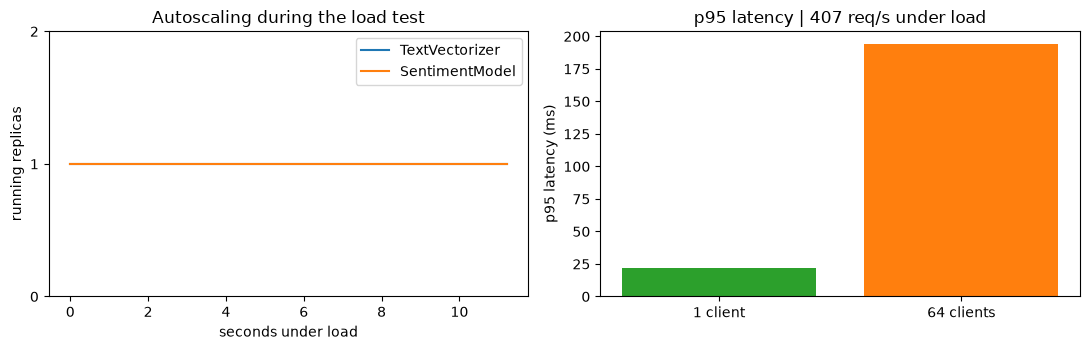

1. Under 64 concurrent clients the app served 407 requests/s (4973 requests, 0 errors) with p95 194 ms, vs p95 21.6 ms for a single client.
2. Batching was active: the model stage averaged 4.6 rows per call (max 26); the vectorizer averaged 4.8.
3. Autoscaling: peak replicas {'TextVectorizer': 1, 'SentimentModel': 1} → no stage needed a second replica at this load.
4. Correctness: every one of 1066 test reviews got exactly the local model's probability; accuracy over HTTP 78.5%, identical to offline evaluation.


Serve and Ray shut down: True


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for stage in ("TextVectorizer", "SentimentModel"):
    axes[0].step(replica_timeline["seconds"], replica_timeline[stage], where="post", label=stage)
axes[0].set(xlabel="seconds under load", ylabel="running replicas", title="Autoscaling during the load test", yticks=[0, 1, 2])
axes[0].legend()
axes[1].bar(["1 client", "64 clients"], [quiet_stats["p95_ms"], busy_stats["p95_ms"]], color=["tab:green", "tab:orange"])
axes[1].set(ylabel="p95 latency (ms)", title=f"p95 latency | {busy_stats['rps']:.0f} req/s under load")
plt.tight_layout()
plt.show()

peak_replicas = {stage: int(replica_timeline[stage].max()) for stage in ("TextVectorizer", "SentimentModel")}
scaled = [stage for stage, n in peak_replicas.items() if n > 1]
print(f"1. Under 64 concurrent clients the app served {busy_stats['rps']:.0f} requests/s "
      f"({busy_stats['requests']} requests, {busy_stats['errors']} errors) with p95 {busy_stats['p95_ms']:.0f} ms, "
      f"vs p95 {quiet_stats['p95_ms']:.1f} ms for a single client.")
print(f"2. Batching was active: the model stage averaged {batch_stats['SentimentModel']['mean_batch']:.1f} rows per call "
      f"(max {batch_stats['SentimentModel']['max_batch']}); the vectorizer averaged {batch_stats['TextVectorizer']['mean_batch']:.1f}.")
print(f"3. Autoscaling: peak replicas {peak_replicas} → "
      + (f"{', '.join(scaled)} scaled out during the test." if scaled else "no stage needed a second replica at this load."))
print(f"4. Correctness: every one of {len(served_probs)} test reviews got exactly the local model's probability; "
      f"accuracy over HTTP {served_accuracy:.1%}, identical to offline evaluation.")

for app_name in list(serve.status().applications):
    serve.delete(app_name)                                   # stop every application and its replicas
ray.shutdown()               # stops the local cluster, Serve included (on a long-lived cluster you'd call serve.shutdown())
print("Serve and Ray shut down:", not ray.is_initialized())

**Stretch goals**
1. Remove `@serve.batch` from both stages (keep everything else) and rerun Step 4. How do throughput and p95 change?
2. Replace TF-IDF with a sentence-transformers embedding stage (as in the BentoML project) and give only that stage more replicas.
3. Put the app in a module and generate a config with `serve build`; change `max_replicas` in YAML and redeploy with `serve run config.yaml`.
4. Add a `Counter` metric of positive vs negative predictions and find it on the metrics endpoint.

### 🗣️ How to talk about this in an interview
- "I built a composed Ray Serve application, FastAPI ingress → TF-IDF vectorizer → logistic regression, where each stage is its own deployment with its own batching and autoscaling config, and the vectorizer's response is passed straight to the model stage through handles."
- "I tuned C on the validation split and touched the test set once. Then I verified all 1,066 test predictions over HTTP matched the offline pipeline exactly, so serving didn't change model behaviour."
- "Under a sustained 64-client HTTP load test I measured throughput and p50/p95/p99, recorded replica counts per second to see the autoscaler react, and read the actual batch sizes from each stage."
- "I set `max_ongoing_requests` above `max_batch_size`, because the default of 5 silently caps batch size, and I kept the autoscaling look-back window above the metrics interval."
- "For production I'd move the config to YAML on a KubeRay RayService, lengthen the downscale delay, add Prometheus alerts on p95 and queue length, and scale the heavy stage (e.g. a GPU embedder) independently."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is Ray Serve, and how does it relate to Ray?**

<details><summary>Show answer</summary>

- **30-second answer:** Ray is a distributed runtime for Python (tasks, actors, an object store, a scheduler across machines). Ray Serve is its model-serving library: deployments run as replica **actors**, a controller actor manages and autoscales them, and per-node proxies take HTTP/gRPC traffic.
- **Go deeper:** Because it's built on Ray, a Serve app can use Ray's resource scheduling (fractional GPUs, placement groups), the object store for large arguments, and the same cluster used for training or data processing (Ray Data, Ray Train).
- **❌ Common wrong answer:** "Ray Serve is a Kubernetes operator." KubeRay is the operator; Serve is a Python library that also runs on a laptop.

</details>

**Q2. Explain deployment, replica, application, ingress, and handle.**

<details><summary>Show answer</summary>

- **30-second answer:** A *deployment* is a class plus serving settings; a *replica* is one running copy (an actor); an *application* is a graph of bound deployments deployed under a name and route prefix; the *ingress* is the deployment that receives external requests; a *handle* is the client used to call a deployment from Python code.
- **Go deeper:** `.bind()` builds the graph lazily; `serve.run` deploys it and returns the ingress handle. `Deployment.options(...)` creates variants of one class with different settings or names.
- **❌ Common wrong answer:** Treating "deployment" and "replica" as synonyms.

</details>

**Q3. Is a DeploymentHandle call in-process or over the network?**

<details><summary>Show answer</summary>

- **30-second answer:** It's a **remote call**: Ray serializes the arguments, routes the call to a replica actor in another process (possibly another machine), and returns a `DeploymentResponse` you `await` (or `.result()` in sync code). There's no HTTP, but there is serialization and IPC/network latency.
- **Go deeper:** Large objects go through the shared-memory object store (zero-copy on the same node). Passing a `DeploymentResponse` into another handle call chains stages without routing the data back through the caller.
- **❌ Common wrong answer:** "Handles use in-process shared memory, so calls are free."

</details>

**Q4. How does Ray Serve autoscale, and why use ongoing requests rather than CPU?**

<details><summary>Show answer</summary>

- **30-second answer:** Replicas report ongoing (queued + running) requests; the controller aims for about `total ongoing ÷ target_ongoing_requests` replicas within `[min_replicas, max_replicas]`, averaged over `look_back_period_s` and gated by `upscale_delay_s` / `downscale_delay_s`. Request load measures demand directly, while CPU is misleading for GPU, batched, or I/O-bound replicas.
- **Go deeper:** Keep `max_ongoing_requests` above the target, scale down slowly to avoid flapping, keep `min_replicas ≥ 1` for latency-sensitive apps (scale-to-zero means cold starts). The Ray autoscaler adds cluster nodes when replicas can't be placed.
- **❌ Common wrong answer:** Using the old `target_num_ongoing_requests_per_replica` key (renamed to `target_ongoing_requests`), or "Serve scales on CPU utilization like HPA."

</details>

**Q5. How does the router pick a replica, and why is "power of two choices" a good idea?**

<details><summary>Show answer</summary>

- **30-second answer:** Ray Serve's default router samples two candidate replicas and sends the request to the one with fewer ongoing requests, respecting `max_ongoing_requests`. Checking two random replicas avoids overloading slow or busy ones (a big tail-latency win over round-robin or random) without the cost and staleness of querying every replica.
- **Go deeper:** It also prefers replicas on the same node or zone and, for multiplexing, replicas that already have the requested model loaded. Our from-scratch experiment showed round-robin's p99 exploding because of one slow replica.
- **❌ Common wrong answer:** "Always pick the globally least-loaded replica" — at scale that needs fresh state from every replica, and many routers acting on the same stale data can all pile onto the same replica (herding).

</details>

**Q6. How is `@serve.batch` different from continuous batching in vLLM?**

<details><summary>Show answer</summary>

- **30-second answer:** `@serve.batch` groups whole requests in one replica (up to `max_batch_size`, waiting up to `batch_wait_timeout_s`) and runs them to completion together, which is ideal for classifiers and embedders. vLLM's continuous batching schedules at every **token step**, adding new sequences and removing finished ones, which LLM generation needs.
- **Go deeper:** Ray Serve LLM delegates batching to vLLM and adds replica scaling, routing (e.g. prefix-cache aware), and the OpenAI-compatible API on top.
- **❌ Common wrong answer:** "Just put `@serve.batch` around `model.generate`."

</details>

### 💻 Coding

**Q7. Write a FastAPI ingress deployment that calls a model deployment.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  app = FastAPI()

  class PredictRequest(BaseModel):
      features: list[float]

  @serve.deployment
  @serve.ingress(app)
  class Api:
      def __init__(self, model: DeploymentHandle):
          self.model = model

      @app.post("/predict")
      async def predict(self, req: PredictRequest) -> dict:
          return {"y": await self.model.predict.remote(req.features)}

  serve.run(Api.bind(Model.bind()), route_prefix="/")
  ```
- **Go deeper:** Put validation in Pydantic models, keep the ingress `async`, and give the model deployment its own `autoscaling_config` and `@serve.batch`.
- **❌ Common wrong answer:** Calling `.result()` inside the async route (raises `RuntimeError` in Ray 2.x), or creating the model inside the request handler.

</details>

**Q8. Implement power-of-two-choices routing.**

<details><summary>Show answer</summary>

- **30-second answer:** `a, b = rng.sample(range(n), 2); return a if load[a] <= load[b] else b`. Increment the chosen replica's load when dispatching and decrement it on completion.
- **Go deeper:** Handle replicas at `max_ongoing_requests` (retry with new samples, back off), stale load info (count in-flight requests locally), and ties (random tie-break).
- **❌ Common wrong answer:** Sampling with replacement, so both choices can be the same replica, or never decrementing the load counter.

</details>

### 🐛 Debugging Scenarios

**Q9. You added `@serve.batch(max_batch_size=64)` but batches never exceed 5. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** `max_ongoing_requests` defaults to 5, so a replica never holds more than 5 requests and the batcher can't collect more. Set `max_ongoing_requests` to at least `max_batch_size` (Pitfall 2 measured the throughput difference).
- **Go deeper:** Also check `batch_wait_timeout_s` (too short = small batches at moderate load) and whether the caller actually sends concurrent requests.
- **❌ Common wrong answer:** "Increase `batch_wait_timeout_s`" — it won't help when the replica isn't allowed to accept more requests.

</details>

**Q10. An application stays in DEPLOYING forever after you set `ray_actor_options={"num_gpus": 1}`. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** No node has a free GPU, so Ray can't place the replica actors and they stay pending. Check `serve.status()` and `ray.cluster_resources()` / `ray.available_resources()`, then add GPU nodes (or enable the cluster autoscaler), lower the request (e.g. `num_gpus=0.5`), or reduce replicas.
- **Go deeper:** Replica logs show nothing because the actor never started; the controller log and `ray status` show the unschedulable resource demand.
- **❌ Common wrong answer:** "The model is too slow to load" without checking whether the replica ever started.

</details>

**Q11. A replica's p99 is terrible although CPU is low. The handler calls a feature store with `requests.get`. What's happening?**

<details><summary>Show answer</summary>

- **30-second answer:** A blocking call runs on the replica's event loop (sync methods run on the loop by default in Ray 2.58), so each request waits for the previous one's I/O. Use an async client (`httpx.AsyncClient`, `aiohttp`) in an `async def` method, or offload with `asyncio.to_thread`. Pitfall 3 measured it.
- **Go deeper:** Also set timeouts on the downstream call and a `max_queued_requests` limit, so a slow dependency sheds load instead of piling up requests.
- **❌ Common wrong answer:** "Add more replicas" — it hides the problem at a much higher cost.

</details>

### 🏗️ Design

**Q12. Design a RAG serving pipeline on Ray Serve: embedder, vector search, reranker, LLM.**

<details><summary>Show answer</summary>

- **30-second answer:** One deployment per stage. A batched embedder on a fractional GPU; retrieval as an async call to a vector DB; a batched cross-encoder reranker on a GPU; the LLM via Ray Serve LLM (vLLM, OpenAI-compatible, tensor parallel if needed). A FastAPI ingress orchestrates with handles, and each stage autoscales on its own ongoing requests.
- **Go deeper:** Stream tokens to the client; cache embeddings and frequent queries; use prefix-cache-aware routing for shared system prompts; multiplex LoRA adapters per tenant; track time-to-first-token, tokens/s, and retrieval quality; set per-stage timeouts and fallbacks.
- **❌ Common wrong answer:** Putting all four models in one deployment, so they can only scale together on the most expensive GPU type.

</details>

**Q13. How do you run Ray Serve in production on Kubernetes?**

<details><summary>Show answer</summary>

- **30-second answer:** Use **KubeRay**: a `RayService` resource holds the Ray cluster spec plus the Serve config (the YAML from `serve build`). KubeRay creates the cluster, deploys the apps, and on updates can bring up a new cluster and switch traffic once it's healthy. Images contain the code; config changes (replicas, autoscaling) are declarative.
- **Go deeper:** Enable GCS fault tolerance (an external Redis) so the head node can restart without losing Serve state; expose Prometheus metrics and Grafana dashboards; use the Ray autoscaler for worker nodes; keep `serve deploy` / config validation in CI.
- **❌ Common wrong answer:** "Run `serve.run` in a Jupyter notebook on the head node."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** What type does `handle.method.remote(x)` return?
<details><summary>Answer</summary>

A **`DeploymentResponse`** — `await` it in async code (and Jupyter), or call `.result()` in a sync script. Section 2 printed the type.
</details>

**2.** What is the default `max_ongoing_requests` of a deployment?
<details><summary>Answer</summary>

**5** — which is why Pitfall 2's batches never exceeded 5 until we raised it.
</details>

**3.** What is the default `target_ongoing_requests` in an autoscaling config?
<details><summary>Answer</summary>

**2** — printed from `AutoscalingConfig()` in section 6.
</details>

**4.** `arr = ray.get(ray.put(np.arange(3)))` — is `arr` writeable?
<details><summary>Answer</summary>

**No** (`arr.flags.writeable` is `False`): NumPy arrays read from the object store are zero-copy, read-only views (section 1). Use `arr.copy()` to modify.
</details>

**5.** With your `p2c_pick` from Exercise 5 and only **two** replicas with queues `[0, 9]`, which index is chosen?
<details><summary>Answer</summary>

Always **0**: with two replicas, both are sampled every time and the shorter queue wins, whatever order `rng.sample` returns them in.
</details>

## 📚 Resources

### 📖 Official Docs
- [Ray Serve: Scalable and Programmable Serving](https://docs.ray.io/en/latest/serve/index.html) — overview and quickstart
- [Key Concepts](https://docs.ray.io/en/latest/serve/key-concepts.html) — deployments, applications, handles, ingress
- [Set Up FastAPI and HTTP](https://docs.ray.io/en/latest/serve/http-guide.html) — `@serve.ingress`
- [Deploy Compositions of Models](https://docs.ray.io/en/latest/serve/model_composition.html) — handles and response chaining
- [Ray Serve Autoscaling](https://docs.ray.io/en/latest/serve/autoscaling-guide.html) — every knob, with guidance
- [Dynamic Request Batching](https://docs.ray.io/en/latest/serve/advanced-guides/dyn-req-batch.html) — `@serve.batch`
- [Model Multiplexing](https://docs.ray.io/en/latest/serve/model-multiplexing.html)
- [Serve Config Files](https://docs.ray.io/en/latest/serve/production-guide/config.html) — `serve build`, `serve deploy`
- [Monitor Your Application](https://docs.ray.io/en/latest/serve/monitoring.html) — logs, metrics, dashboards
- [Serving LLMs](https://docs.ray.io/en/latest/serve/llm/index.html) — Ray Serve LLM with vLLM
- [What's Ray Core?](https://docs.ray.io/en/latest/ray-core/walkthrough.html) — tasks, actors, objects
- [Ray on Kubernetes](https://docs.ray.io/en/latest/cluster/kubernetes/index.html) — KubeRay and RayService

### 🎥 Videos
- [Zachary Huang — Ray in 30 min](https://www.youtube.com/watch?v=4Rbd_1Kb2qU) (29 min) — a clear, code-first tour of Ray core before you go deeper into Serve
- [Arize AI — Ray Serve: Tutorial for Building Real Time Inference Pipelines](https://www.youtube.com/watch?v=9aud-oh5NEE) (33 min) — deployments, composition, and scaling walked through end to end
- [Anyscale — Deploying Many Models Efficiently with Ray Serve](https://www.youtube.com/watch?v=QUYucglQzBw) (26 min) — multiplexing and model composition from the Ray Serve team
- [Anyscale — Enabling Cost-Efficient LLM Serving with Ray Serve](https://www.youtube.com/watch?v=TJ5K1CO9Wbs) (30 min) — how LLM serving on Ray is put together

### 📄 Papers
- [Ray: A Distributed Framework for Emerging AI Applications (OSDI 2018)](https://arxiv.org/abs/1712.05889) — the tasks/actors/object-store design Serve builds on
- [The Tail at Scale (Dean & Barroso, 2013)](https://research.google/pubs/the-tail-at-scale/) — why replica routing and p99 matter
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (vLLM)](https://arxiv.org/abs/2309.06180) — the engine behind Ray Serve LLM
- [Orca: A Distributed Serving System for Transformer-Based Generative Models (OSDI 2022)](https://www.usenix.org/conference/osdi22/presentation/yu) — continuous (iteration-level) batching

### 📘 Books & Courses
- [Made With ML — Model Serving](https://madewithml.com/courses/mlops/serving/) — free MLOps course chapter that serves a model with Ray Serve
- [Full Stack Deep Learning — Lecture 5: Deployment](https://fullstackdeeplearning.com/course/2022/lecture-5-deployment/) — framework-independent serving concepts

### 🏋️ Practice
- [Ray on GitHub](https://github.com/ray-project/ray) — read `python/ray/serve` (e.g. the request router) and the Serve examples in the docs
- [Locust documentation](https://docs.locust.io/en/stable/) — realistic load tests for your Serve apps
- [NVIDIA Triton — Batchers](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/batcher.html) — compare Triton's dynamic batching with `@serve.batch`

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Ray core | parallel functions and stateful workers | `@ray.remote`, `.remote()`, `ray.get`, `ray.put` (read-only zero-copy arrays) |
| Start Serve | controller + HTTP proxy | `ray.init(num_cpus=...)`, `serve.start(http_options={"host", "port"})` |
| Deployment | a served class + settings | `@serve.deployment(num_replicas=, ray_actor_options=, max_ongoing_requests=)` |
| Deploy | build and run an app | `app = Cls.bind(args)`; `handle = serve.run(app, name=, route_prefix=)`; `serve.delete(name)` |
| Call | remote call via handle | `await handle.method.remote(x)` (async/Jupyter) · `.result()` (sync scripts only) |
| HTTP | FastAPI routes on a deployment | `@serve.deployment` + `@serve.ingress(app)`; invalid input → 422 |
| Composition | multi-stage graphs | pass handles to `__init__`; chain `b.remote(a.remote(x))`; `asyncio.gather` to fan out |
| Batching | many calls → one model call | `@serve.batch(max_batch_size=, batch_wait_timeout_s=)` + `max_ongoing_requests ≥ max_batch_size` |
| Autoscaling | replicas follow demand | `autoscaling_config={min_replicas, max_replicas, target_ongoing_requests, upscale/downscale_delay_s, look_back_period_s}` |
| Resources | placement | `{"num_cpus": 0.5, "num_gpus": 0.25, "memory": bytes}` — scheduling, not isolation |
| Multiplexing | many models, shared replicas | `@serve.multiplexed(max_num_models_per_replica=)`, `serve.get_multiplexed_model_id()`, `handle.options(multiplexed_model_id=)` |
| Config | declarative deploys | `serve build mod:app -o cfg.yaml`, `serve run cfg.yaml`, `serve deploy cfg.yaml`, `ServeDeploySchema` |
| Observability | health, logs, metrics | `serve.status()`, `session_dir/logs/serve/`, `ray_serve_*` Prometheus metrics, `ray.serve.metrics.Counter` |
| Routing | replica choice | power of two choices (default): sample 2, pick fewer ongoing requests |
| LLMs | OpenAI-compatible LLM serving | `ray.serve.llm.LLMConfig` + `build_openai_app` (vLLM engine, needs GPUs) |
| Shutdown | clean up | `serve.delete(app)` · `serve.shutdown()` · `ray.shutdown()` |

## ➡️ What's Next

**[16 · Agentic AI — Agent Architectures & Workflow Patterns](../16_Agentic_AI/01_Agent_Architectures_and_Workflow_Patterns.ipynb)** — you can now serve models at scale. The study plan continues with the Agentic AI module: designing, evaluating, securing and shipping AI agents on top of the serving skills from this module. Data processing with [Polars](../11_Data_Processing/01_Polars.ipynb) comes after the Agentic AI and Multimodal modules.